# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

Fone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [110]:
# Import warnings
import numpy as np
import pandas as pd
import os


In [111]:
# Import the libraries you will be using for analysis
import matplotlib.pyplot as plt
import seaborn as sns


In [112]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.3.3
matplotlib version: 3.9.4
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [499]:
# Try loading one file

df1 = pd.read_parquet('trip_records/2023-1.parquet', engine='fastparquet')
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload
# Load the new data file
def sample_data(df, random_state=42,max_sample_size=1000,sample_fraction=0.05):
    """
    Sample data by taking a percentage of values randomly from every hour of each date.
    will take min of sample_fraction of the data or max_sample_size
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the taxi data with 'tpep_pickup_datetime' column
    random_state : int, default=42
        Random seed for reproducibility
    max_sample_size : int, default=1000
        Maximum number of samples to take from each hour (5% of the data or max_sample_size)
    sample_fraction : float, default=0.05
        Fraction of data to sample from each hour (0.05 = 5%)
    """
    
    # Ensure tpep_pickup_datetime is datetime type
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    
    # Extract date and hour for grouping
    df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    
    # Initialize empty DataFrame to store sampled data
    sampled_data = pd.DataFrame()
    sampled_list = []
    # Group by date and hour, then sample from each group
    grouped = df.groupby(['pickup_date', 'pickup_hour'])   
    
    for (date, hour), group_data in grouped:
        # Sample the specified fraction from this hour's data
        group_size = len(group_data)

        # Compute sample size: min(5%, max_sample_size)
        sample_size = min(
            int(group_size * sample_fraction),
            max_sample_size
        )

        # Ensure at least 1 row if group is non-empty
        if sample_size > 0:
            sampled_list.append(group_data.sample(
                    n=sample_size,
                    random_state=random_state
                ))

    # Drop the temporary columns
    sampled_data = pd.concat(sampled_list)
    sampled_data.drop(columns=['pickup_date', 'pickup_hour'], inplace=True)
    return sampled_data


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
#os.chdir('/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        # We will store sample of whole data of month in sampled_data, and process it date and hour wise
        # After completing iteration through each months we will append it in the dinal dataframe
        sampled_data = pd.read_parquet(file_path, engine='fastparquet')

        """The below method picks aggregates the data date and month wile
        and samples 5% of the data or 35 records, whever is minimum, randomly to ensure that there is representation of all the data
        for each day we get 24*35 max records which gives us roughly 300K records annualy"""
        sampled_data = sample_data(sampled_data,42,35)

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data])

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
# df.to_parquet('')
# getting 300K records, which we can prosceed with next steps
df.info()
df.to_parquet('2023-annual-consolidated.parquet')


<class 'pandas.core.frame.DataFrame'>
Index: 298312 entries, 3791 to 3202909
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               298312 non-null  int64         
 1   tpep_pickup_datetime   298312 non-null  datetime64[us]
 2   tpep_dropoff_datetime  298312 non-null  datetime64[us]
 3   passenger_count        285749 non-null  float64       
 4   trip_distance          298312 non-null  float64       
 5   RatecodeID             285749 non-null  float64       
 6   store_and_fwd_flag     285749 non-null  object        
 7   PULocationID           298312 non-null  int64         
 8   DOLocationID           298312 non-null  int64         
 9   payment_type           298312 non-null  int64         
 10  fare_amount            298312 non-null  float64       
 11  extra                  298312 non-null  float64       
 12  mta_tax                298312 non-null  float

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file

df = pd.read_parquet('trip_records/2023-annual-consolidated.parquet')    


In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
index,,,,,,,,,,,,,,,,,,,,
3791,2,2023-11-30 23:58:12,2023-12-01 00:06:58,1.0,1.31,1.0,N,163,162,1,10.00,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.0,NaN
1788,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,23.30,1.0,0.5,5.66,0.0,1.0,33.96,2.5,0.0,NaN
3196699,2,2023-12-01 00:38:48,2023-12-01 01:01:55,NaN,4.79,NaN,None,231,61,0,22.43,0.0,0.5,3.00,0.0,1.0,29.43,NaN,NaN,NaN
1408,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,10.70,1.0,0.5,3.14,0.0,1.0,18.84,2.5,0.0,NaN
3196663,2,2023-12-01 00:00:50,2023-12-01 00:14:37,NaN,2.08,NaN,None,137,144,0,17.22,0.0,0.5,0.00,0.0,1.0,21.22,NaN,NaN,NaN


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 298312 entries, 3791 to 3202909
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               298312 non-null  int64         
 1   tpep_pickup_datetime   298312 non-null  datetime64[us]
 2   tpep_dropoff_datetime  298312 non-null  datetime64[us]
 3   passenger_count        285749 non-null  float64       
 4   trip_distance          298312 non-null  float64       
 5   RatecodeID             285749 non-null  float64       
 6   store_and_fwd_flag     285749 non-null  object        
 7   PULocationID           298312 non-null  int64         
 8   DOLocationID           298312 non-null  int64         
 9   payment_type           298312 non-null  int64         
 10  fare_amount            298312 non-null  float64       
 11  extra                  298312 non-null  float64       
 12  mta_tax                298312 non-null  float

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed
#Dropping index of the dataframe
df.reset_index(drop=True,inplace=True)





In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 278132 entries, 0 to 298311
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   vendor_id              278132 non-null  int64         
 1   tpep_pickup_datetime   278132 non-null  datetime64[us]
 2   tpep_dropoff_datetime  278132 non-null  datetime64[us]
 3   passenger_count        278132 non-null  int64         
 4   trip_distance          278132 non-null  float64       
 5   ratecode_id            278132 non-null  int64         
 6   store_and_fwd_flag     278132 non-null  object        
 7   pu_location_id         278132 non-null  int64         
 8   do_location_id         278132 non-null  int64         
 9   payment_type           278132 non-null  int64         
 10  fare_amount            278132 non-null  float64       
 11  extra                  278132 non-null  float64       
 12  mta_tax                278132 non-null  float64  

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Check rows where both columns have non-null values
both_non_null = df[['Airport_fee', 'airport_fee']].notna().all(axis=1).sum()
print(f"Rows with both columns non-null: {both_non_null}")
 

Rows with both columns non-null: 0


In [ ]:
# Combine the two airport fee columns
#as we see both columns dont have any such entry, hence we can safely merge them and drop one
df['airport_fee'] = df['airport_fee'].combine_first(df['Airport_fee'])
df = df.drop('Airport_fee', axis=1)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298312 entries, 0 to 298311
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               298312 non-null  int64         
 1   tpep_pickup_datetime   298312 non-null  datetime64[us]
 2   tpep_dropoff_datetime  298312 non-null  datetime64[us]
 3   passenger_count        285749 non-null  float64       
 4   trip_distance          298312 non-null  float64       
 5   RatecodeID             285749 non-null  float64       
 6   store_and_fwd_flag     285749 non-null  object        
 7   PULocationID           298312 non-null  int64         
 8   DOLocationID           298312 non-null  int64         
 9   payment_type           298312 non-null  int64         
 10  fare_amount            298312 non-null  float64       
 11  extra                  298312 non-null  float64       
 12  mta_tax                298312 non-null  floa

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative
df[df['total_amount'] < 0]['total_amount'].count()

np.int64(11)

Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts

df[df['total_amount'] < 0]['RatecodeID'].value_counts()



RatecodeID
2.0    6
1.0    4
3.0    1
Name: count, dtype: int64

In [ ]:
# Find which columns have negative values
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cols_with_negatives =[]
for col in numeric_cols:
    if (df[col] < 0).any():
        cols_with_negatives.append(col)
print(cols_with_negatives)

df[df['total_amount'] < 0][cols_with_negatives+['fare_amount','trip_distance']]

['extra', 'mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


,extra,mta_tax,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,fare_amount,trip_distance
6732,0.0,-0.5,-1.0,-4.00,-2.5,0.00,0.0,0.00
13236,0.0,-0.5,-1.0,-3.25,0.0,-1.75,0.0,11.27
23056,0.0,-0.5,-1.0,-4.00,-2.5,0.00,0.0,0.02
34278,0.0,-0.5,-1.0,-4.00,-2.5,0.00,0.0,3.61
113472,0.0,-0.5,-1.0,-3.25,0.0,-1.75,0.0,0.05
127764,0.0,-0.5,-1.0,-4.00,-2.5,0.00,0.0,0.00
154424,0.0,-0.5,-1.0,-4.00,-2.5,0.00,0.0,0.01
178722,0.0,0.0,-1.0,-1.00,0.0,0.00,0.0,17.07
255344,0.0,-0.5,-1.0,-1.50,0.0,0.00,0.0,0.00
293576,0.0,-0.5,-1.0,-4.00,-2.5,0.00,0.0,1.09


In [ ]:
# fix these negative values
# as we see the in our dataset there are only 11 rows with negative values,
# we observe that these are distributed among rate code ID 1,2 and 3 so there is no clear co relation with rate code
# further we observe that they are not proportional to trip distance, hence they cannot be some error in marking them negative, 
# hence we cannot consider absolute value of these trips, and factoring the extreamly small number of entries(11 in 400K),
#we drop these entries
df = df[df['total_amount'] >= 0]

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column

(df.isnull().sum()/len(df))*100

VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          4.211518
trip_distance            0.000000
RatecodeID               4.211518
store_and_fwd_flag       4.211518
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     4.211518
airport_fee              4.211518
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'

#df[(df['passenger_count']==0) | (df['passenger_count'].isnull())]['passenger_count'].shape[0]/len(df) * 100
# To impute the number of passengers where the number is null we will be filling mode value of passengers where there is null value
# We can consider mean, because taking mean will land us with fractions, and we can't have a fraction of a passenger.
pc_mode = df[ (df['passenger_count']>0) | (df['passenger_count'].notnull()) ]['passenger_count'].mode()[0]
print(pc_mode )
df['passenger_count'] = df['passenger_count'].fillna(pc_mode)

1.0


Did you find zeroes in passenger_count? Handle these.

In [ ]:
#To handle the 0 passenget_count we again follow the above method, fill them with mode
df['passenger_count'] = df['passenger_count'].replace(0, pc_mode)
#validating there are no null and 0 values
df[(df['passenger_count']==0) | (df['passenger_count'].isnull())]['passenger_count'].shape[0]/len(df) * 100

0.0

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

#Finding missing RatecodeID

In [ ]:
#finding null or missing ratecodeIDs 
df[(df['RatecodeID']==99) | (df['RatecodeID'].isnull())]['RatecodeID'].shape[0]/len(df) * 100


5.008699266847915

In [ ]:
# Fix missing values in 'RatecodeID'
#will mark the records where rate code is missing with the mode of the rate code
mode_rate_code = df['RatecodeID'].mode()[0]
print(mode_rate_code)
#filling NA with mode_rate_code ratecode
df['RatecodeID'] = df['RatecodeID'].fillna(mode_rate_code)
#filling 99 with mode_rate_code ratecode
df['RatecodeID'] = df['RatecodeID'].replace(99,mode_rate_code)


#validate all data is replaced
df[(df['RatecodeID']==99) | (df['RatecodeID'].isnull())]['RatecodeID'].shape[0]/len(df) * 100

1.0


0.0

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge

# We will replace the null values of congestion surcharge with 0
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

# check null values in congestion_surcharge
df['congestion_surcharge'].isnull().sum()



np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values

#Handling the airport_fee column, replacing null values with 0
df['airport_fee'] = df['airport_fee'].fillna(0)


#Handling the store_and_fwd_flag column, replacing null values with N as if the trip was stored, we would have got the value Y
# null value indicates a non-stored trip
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('N')

#Validating all null columns  are handeled 
df.isnull().sum()/len(df)*100

VendorID                 0.0
tpep_pickup_datetime     0.0
tpep_dropoff_datetime    0.0
passenger_count          0.0
trip_distance            0.0
RatecodeID               0.0
store_and_fwd_flag       0.0
PULocationID             0.0
DOLocationID             0.0
payment_type             0.0
fare_amount              0.0
extra                    0.0
mta_tax                  0.0
tip_amount               0.0
tolls_amount             0.0
improvement_surcharge    0.0
total_amount             0.0
congestion_surcharge     0.0
airport_fee              0.0
dtype: float64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

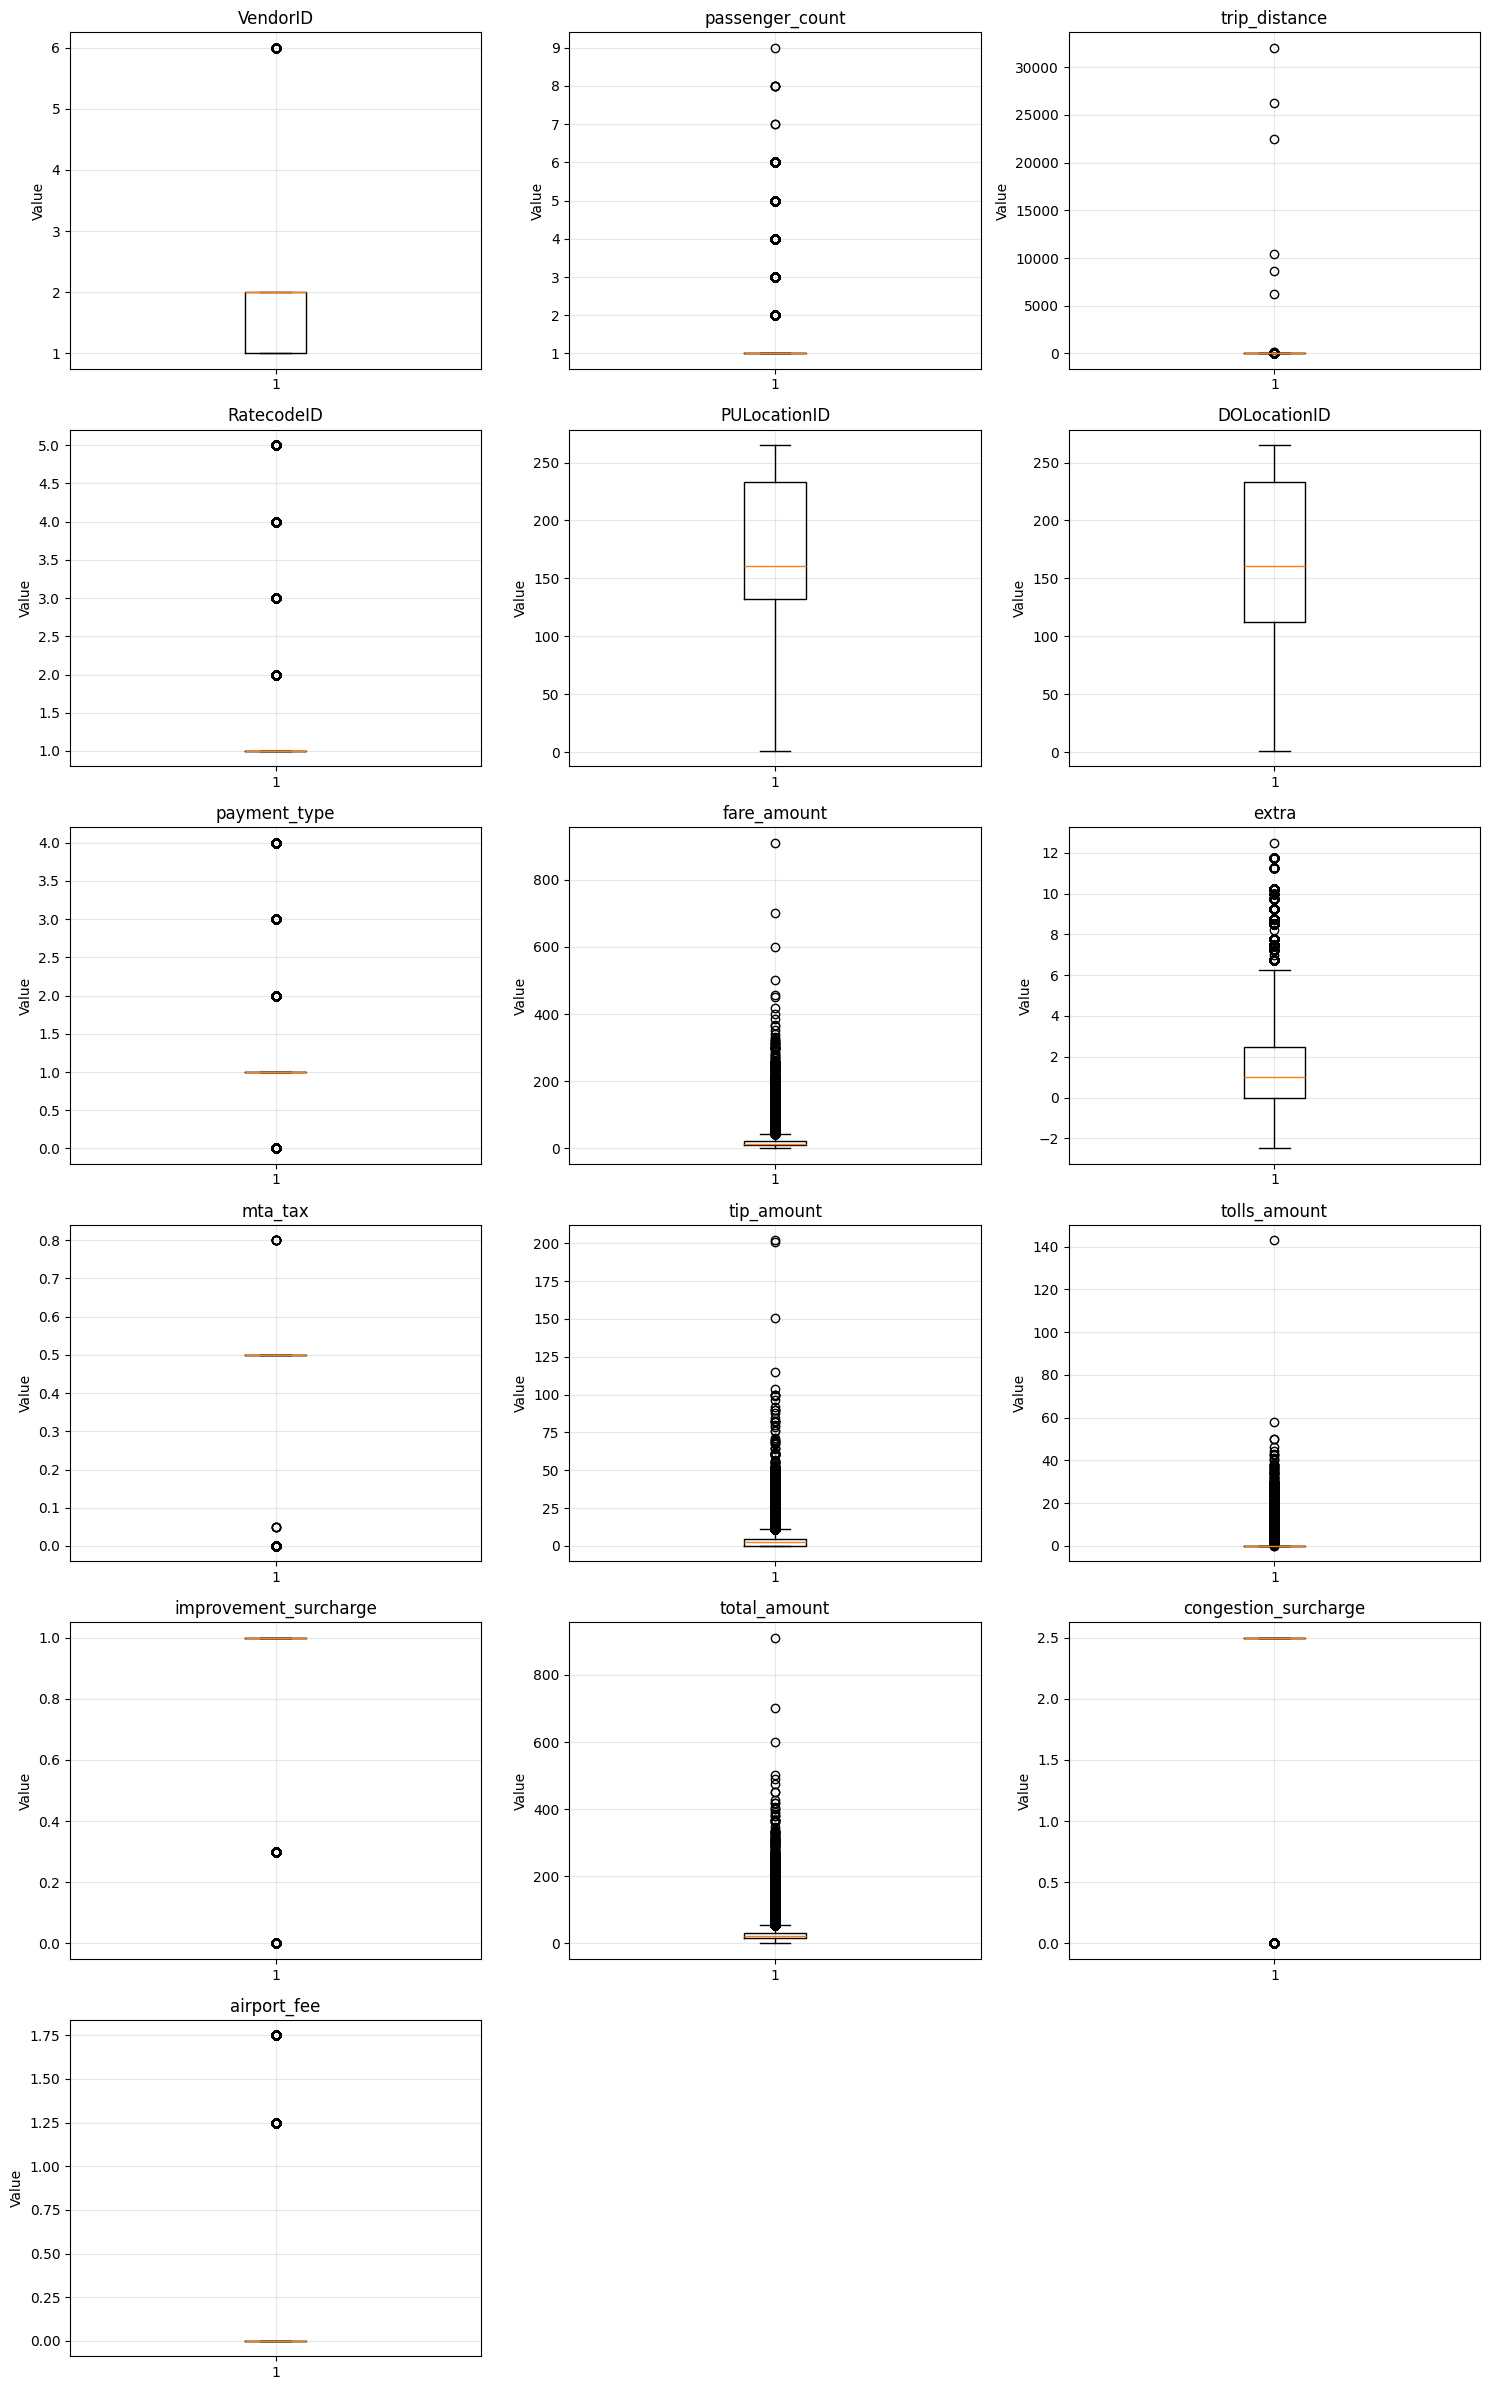

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe()
numeric_columns = df.columns[(df.dtypes == 'float64') | (df.dtypes == 'int64')].to_list()


# Calculate number of rows needed for 3 columns
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
 
# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()  # Flatten to make indexing easier
 
# Plot each numeric column
for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)
 
# Hide empty subplots if any
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')
 
plt.tight_layout()
plt.show()



**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]


In [ ]:
# Continue with outlier handling
# From the charts above we can see that there are outliers in 
#['trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']

#Lets deal with trip distance first
#from the description of trip distance we see there the mean is aprox 4 and standard diviation is 90, which is huge
#indicating lot of incorrect data, lets divide the distance in range and check what each range contains,

bins = [0, 50, 100, 150, 200, 250, float('inf')]
labels = ['0-50', '50-100', '100-150', '150-200', '200-250', '250+']
df['distance_category'] = pd.cut(df['trip_distance'], bins=bins, labels=labels, right=False)
df['distance_category'].value_counts()

distance_category
0-50       298245
50-100         41
250+            6
100-150         1
150-200         1
200-250         0
Name: count, dtype: int64

In [ ]:
#as we see the data above 100  are skewing the data, lets remove them
df = df[df['trip_distance'] <= 100]

# lets filter the cases where trip distance is non zero by pickup and drop location are different
df = df[(df['DOLocationID'] != df['PULocationID']) & (df['trip_distance'] > 0)]

#checking all identified columns with potential outliers after cleaning trip_distance
df[['trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']].describe()



,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount
count,278488.000000,278488.000000,278488.000000,278488.000000,278488.000000
mean,3.984202,20.866898,3.667017,0.707609,30.096516
std,4.903427,18.801218,4.195331,2.387383,23.638485
min,0.010000,0.000000,0.000000,0.000000,0.000000
25%,1.200000,9.300000,1.000000,0.000000,16.120000
50%,2.000000,14.200000,2.860000,0.000000,21.380000
75%,4.150000,24.000000,4.540000,0.000000,32.400000
max,75.500000,455.200000,150.290000,50.000000,488.700000


In [ ]:
## as we see very less trips have tolls hence we cannot remove tolls as they are legitimate
##we can trips where tip_amount is more than fare_amount as they are not what we are intrested in
df = df[df['tip_amount'] <= df['fare_amount']]


In [ ]:
# Do any columns need standardising?
#dropping distance_category column added for analysys
df = df.drop('distance_category', axis=1)

# Rename columns to standard names
df.rename(columns={
    'VendorID': 'vendor_id',
    'RatecodeID': 'ratecode_id',
    'PULocationID': 'pu_location_id',
    'DOLocationID': 'do_location_id'
}, inplace=True)

#changing data type of columns
df['passenger_count'] = df['passenger_count'].astype('int64')
df['ratecode_id'] = df['ratecode_id'].astype('int64')

<class 'pandas.core.frame.DataFrame'>
Index: 278165 entries, 0 to 298311
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   vendor_id              278165 non-null  int64         
 1   tpep_pickup_datetime   278165 non-null  datetime64[us]
 2   tpep_dropoff_datetime  278165 non-null  datetime64[us]
 3   passenger_count        278165 non-null  int64         
 4   trip_distance          278165 non-null  float64       
 5   ratecode_id            278165 non-null  int64         
 6   store_and_fwd_flag     278165 non-null  object        
 7   pu_location_id         278165 non-null  int64         
 8   do_location_id         278165 non-null  int64         
 9   payment_type           278165 non-null  int64         
 10  fare_amount            278165 non-null  float64       
 11  extra                  278165 non-null  float64       
 12  mta_tax                278165 non-null  float64  

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

['vendor_id',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'ratecode_id',
 'store_and_fwd_flag',
 'pu_location_id',
 'do_location_id',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_hour',
 'pickup_day_of_week',
 'pickup_day_num',
 'pickup_month',
 'pickup_month_num']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

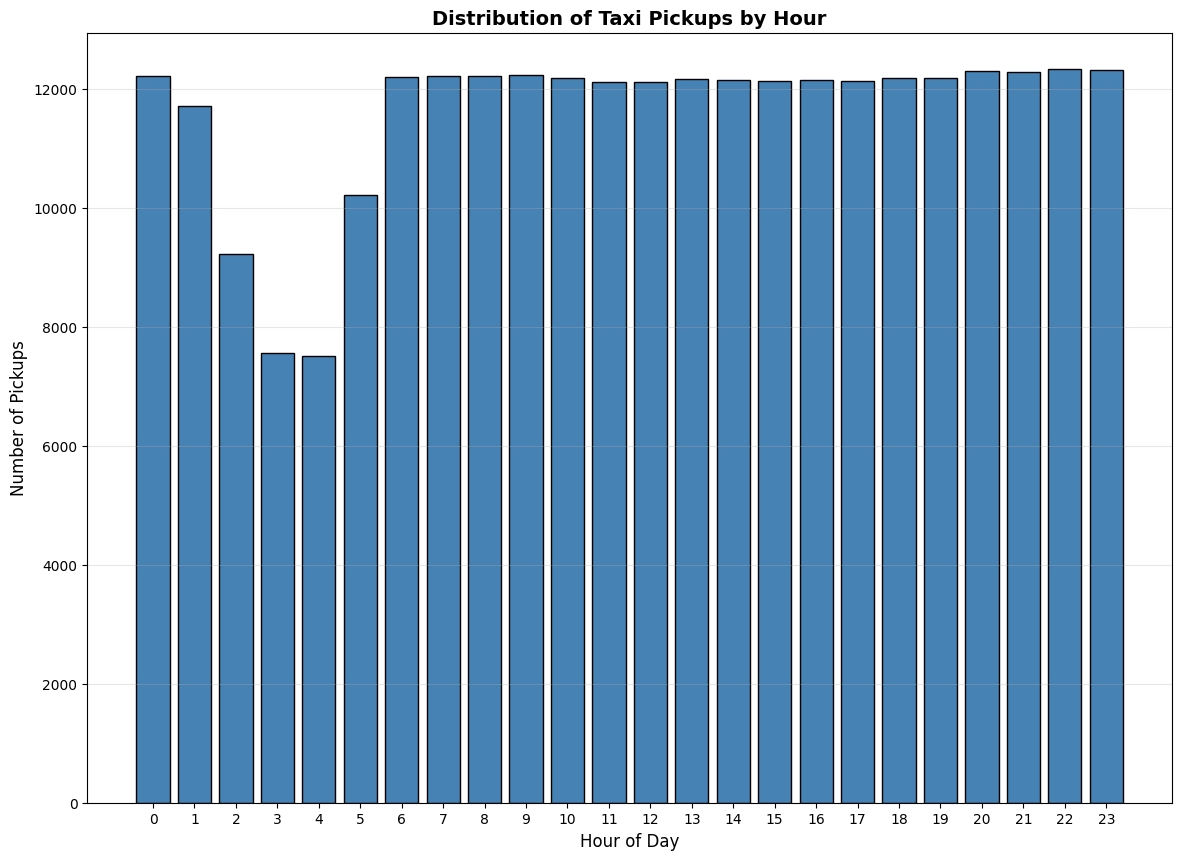

In [482]:
# Find and show the hourly trends in taxi pickups
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
fig, axes = plt.subplots(1, 1, figsize=(14, 10))
 
# 1. Hourly Distribution
hourly_pickups = df['pickup_hour'].value_counts().sort_index()
axes.bar(hourly_pickups.index, hourly_pickups.values, color='steelblue', edgecolor='black')
axes.set_xlabel('Hour of Day', fontsize=12)
axes.set_ylabel('Number of Pickups', fontsize=12)
axes.set_title('Distribution of Taxi Pickups by Hour', fontsize=14, fontweight='bold')
axes.set_xticks(range(0, 24))
axes.grid(axis='y', alpha=0.3)

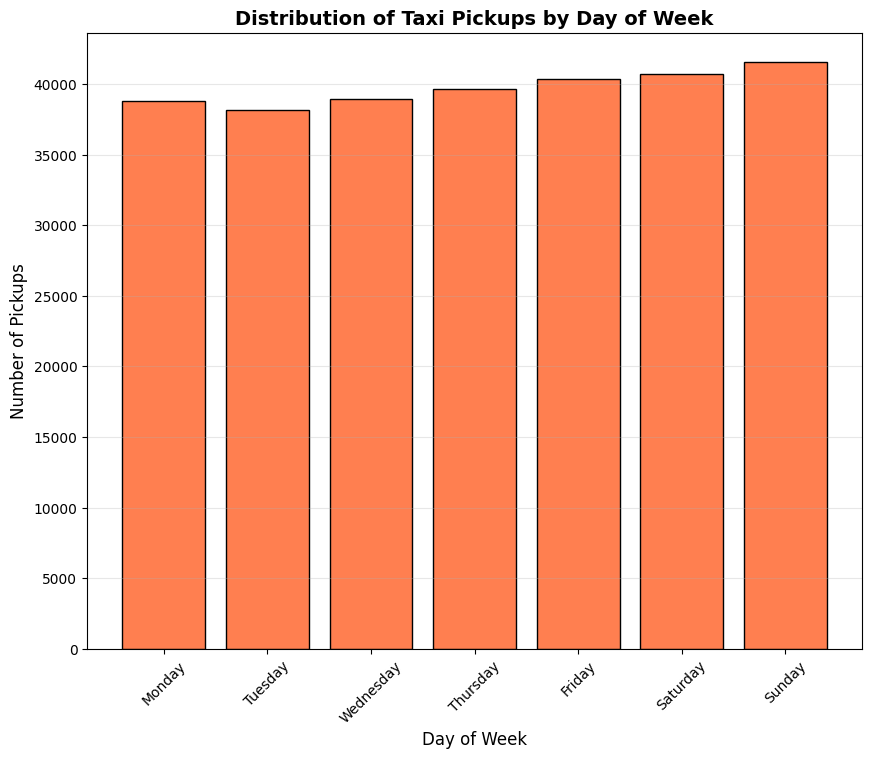

In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.day_name() 

# 2. Day of Week Distribution
fig, axes = plt.subplots(1, 1, figsize=(10, 8))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_pickups = df['pickup_day_of_week'].value_counts().reindex(day_order)
axes.bar(day_pickups.index, day_pickups.values, color='coral', edgecolor='black')
axes.set_xlabel('Day of Week', fontsize=12)
axes.set_ylabel('Number of Pickups', fontsize=12)
axes.set_title('Distribution of Taxi Pickups by Day of Week', fontsize=14, fontweight='bold')
axes.tick_params(axis='x', rotation=45)
axes.grid(axis='y', alpha=0.3)


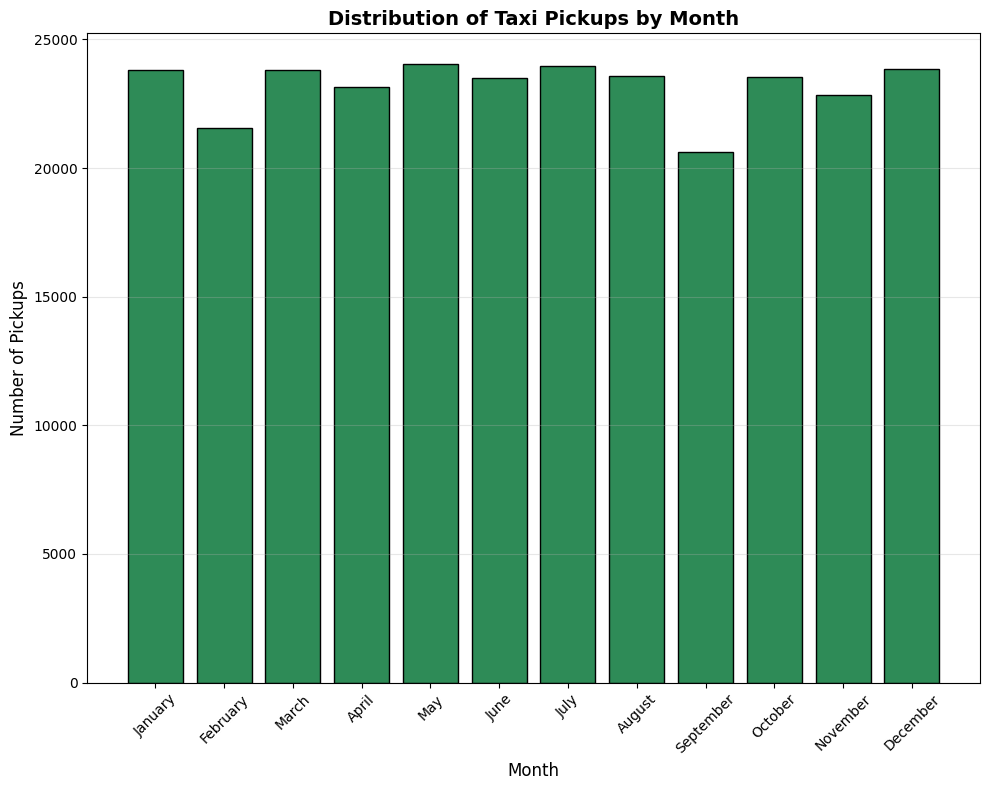

In [ ]:
# Show the monthly trends in pickups
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
fig, axes = plt.subplots(1, 1, figsize=(10, 8))

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_pickups = df['pickup_month'].value_counts().reindex(month_order)
axes.bar(month_pickups.index, month_pickups.values, color='seagreen', edgecolor='black')
axes.set_xlabel('Month', fontsize=12)
axes.set_ylabel('Number of Pickups', fontsize=12)
axes.set_title('Distribution of Taxi Pickups by Month', fontsize=14, fontweight='bold')
axes.tick_params(axis='x', rotation=45)
axes.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [75]:
# Analyse the above parameters

#Rows with 0  values in trip_distance, fare_amount, tip_amount, and total_amount
df[(df['trip_distance'] <= 0) | (df['fare_amount'] <= 0) | (df['tip_amount'] <= 0) | (df['total_amount'] <= 0)][['fare_amount','tip_amount','total_amount','trip_distance']].head(5)

,fare_amount,tip_amount,total_amount,trip_distance
4,17.22,0.0,21.22,2.08
22,10.00,0.0,15.00,1.29
28,17.83,0.0,21.83,3.49
29,19.80,0.0,24.80,3.40
44,30.30,0.0,35.30,6.30


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [126]:
# Create a df with non zero entries for the selected parameters.

#We should not remove records with tip amount 0, as 0 tip can be a scenario where tip was not given
#We can also not remove where pick up and drop off locations are same and fare amount is more than 0,

#However we can delete those records safely where total_amount is 0 but distance is not zero, as those are suspecious rides
#can be part of discount or promotional rides but we do not want that for our aalysis

#Removing rides where total_amount is 0 but distance is not zero
df = df[(df['total_amount'] > 0) & (df['trip_distance'] > 0)]

#Removing rides where fare_amount is 0 but distance is not zero
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0)]



**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

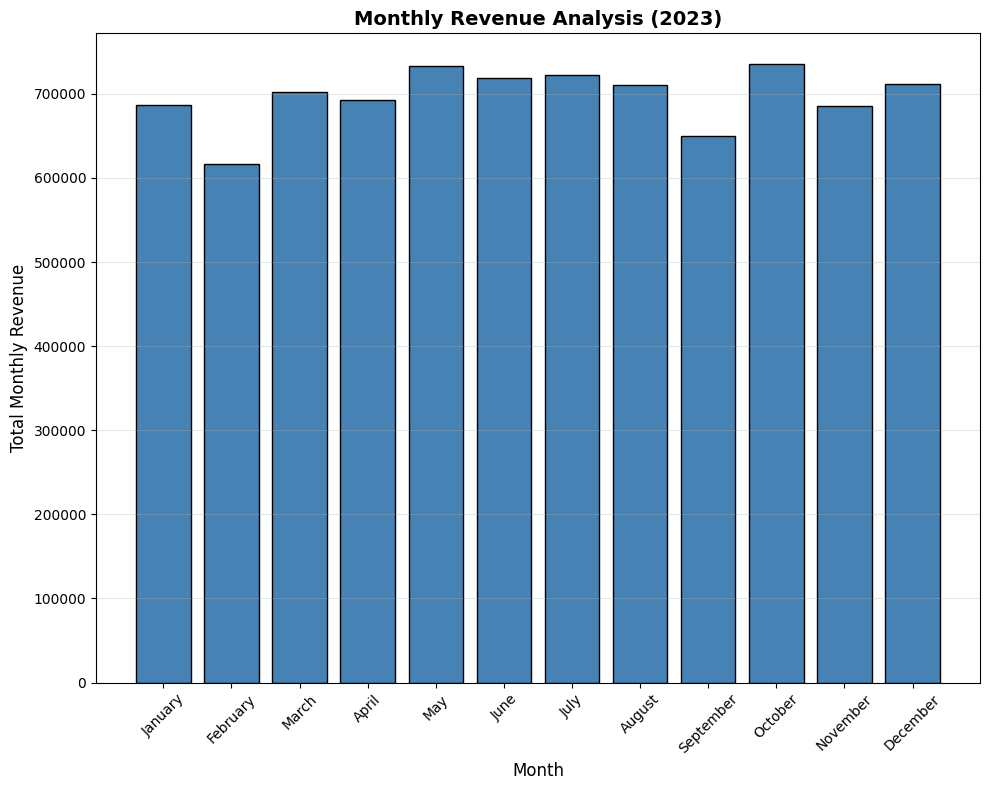

In [490]:
# Group data by month and analyse monthly revenue


monthly_revenue = df.groupby('pickup_month')['total_amount'].sum().reindex(month_order)

fig, axes = plt.subplots(1, 1, figsize=(10, 8))

axes.bar(monthly_revenue.index, monthly_revenue.values, color='steelblue', edgecolor='black')
axes.set_xlabel('Month', fontsize=12)
axes.set_ylabel('Total Monthly Revenue', fontsize=12)
axes.set_title('Monthly Revenue Analysis (2023)', fontsize=14, fontweight='bold')
axes.tick_params(axis='x', rotation=45)
axes.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

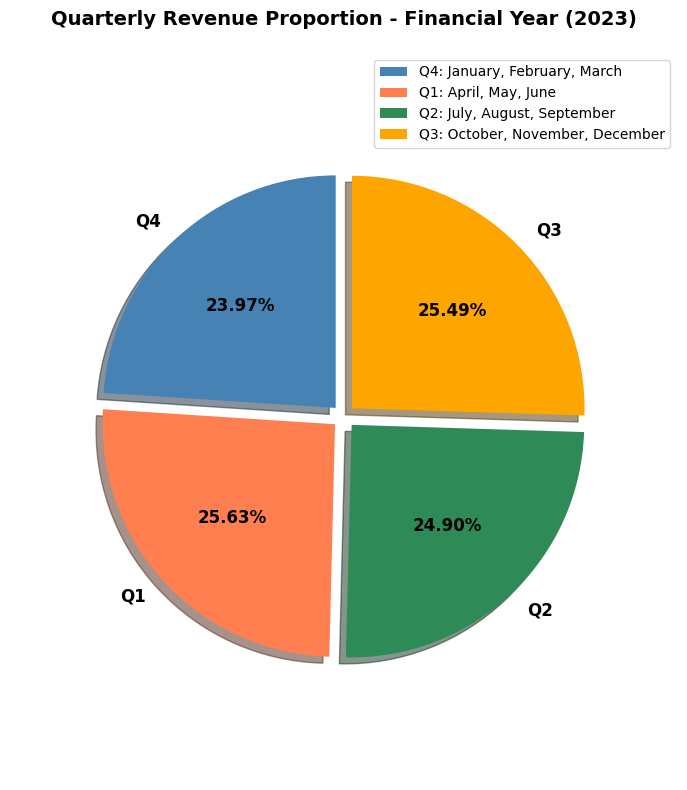

In [ ]:
# Calculate proportion of each quarter

quarters = {
    'Q1': ['April', 'May', 'June'],
    'Q2': ['July', 'August', 'September'],
    'Q3': ['October', 'November', 'December'],
    'Q4': ['January', 'February', 'March']
}
 
# Create a mapping function to assign quarters
def assign_quarter(month):
    for quarter, months in quarters.items():
        if month in months:
            return quarter
    return None
 
# Create quarter column
df['quarter'] = df['pickup_month'].apply(assign_quarter)
 
# Calculate quarterly revenue
quarterly_revenue = df.groupby('quarter')['total_amount'].sum()
 
# Sort quarters in order Q4, Q1, Q2, Q3 (Financial calander)
quarterly_revenue = quarterly_revenue.reindex(['Q4','Q1', 'Q2', 'Q3'])
 
# Calculate proportion of each quarter
quarterly_proportion = (quarterly_revenue / quarterly_revenue.sum()) * 100
 
# Create pie chart
plt.figure(figsize=(10, 8))
colors = ['steelblue', 'coral', 'seagreen', 'orange']
explode = (0.05, 0.05, 0.05, 0.05)
 
plt.pie(quarterly_revenue.values, 
        labels=quarterly_revenue.index, 
        autopct='%1.2f%%',
        startangle=90,
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

legend_labels = [f"{q}: {', '.join(quarters[q])}" for q in ['Q4', 'Q1', 'Q2', 'Q3']]
plt.legend(legend_labels, loc='best', bbox_to_anchor=(1, 1), fontsize=10)
 
plt.title('Quarterly Revenue Proportion - Financial Year (2023)', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()
 


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

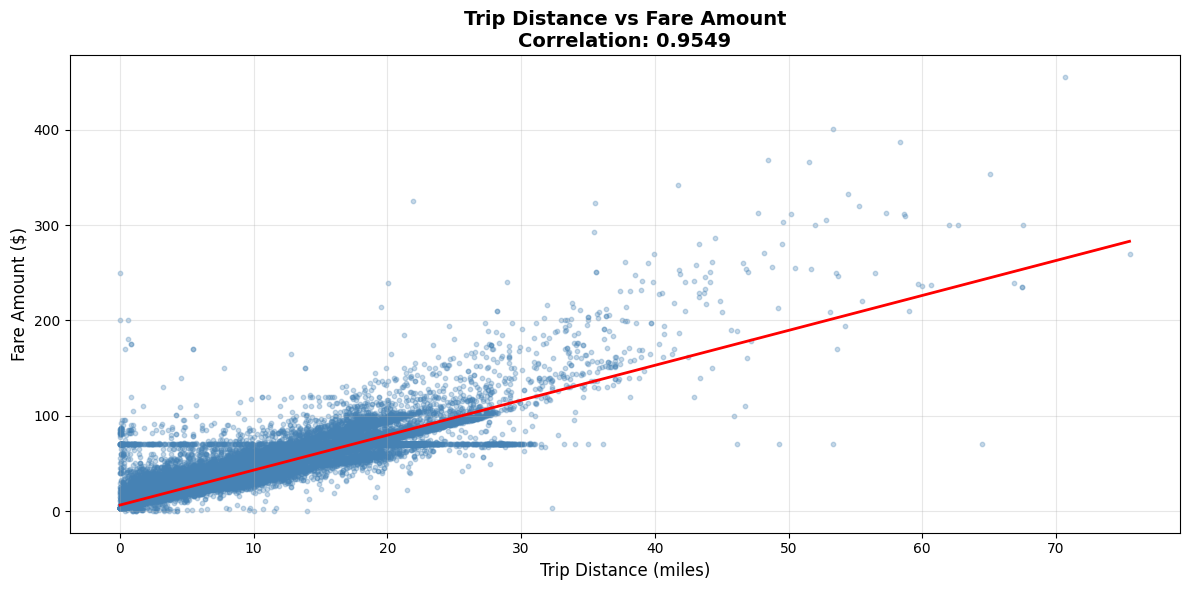

In [146]:
# Show how trip fare is affected by distance

# as we do not have any trips with trip_distance = 0, we can plot fare_amount vs trip_distance

correlation_filtered = df['trip_distance'].corr(df['fare_amount'])
 
plt.figure(figsize=(12, 6))
sns.regplot(x='trip_distance', y='fare_amount', data=df,
            scatter_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.title(f'Trip Distance vs Fare Amount\nCorrelation: {correlation_filtered:.4f}', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

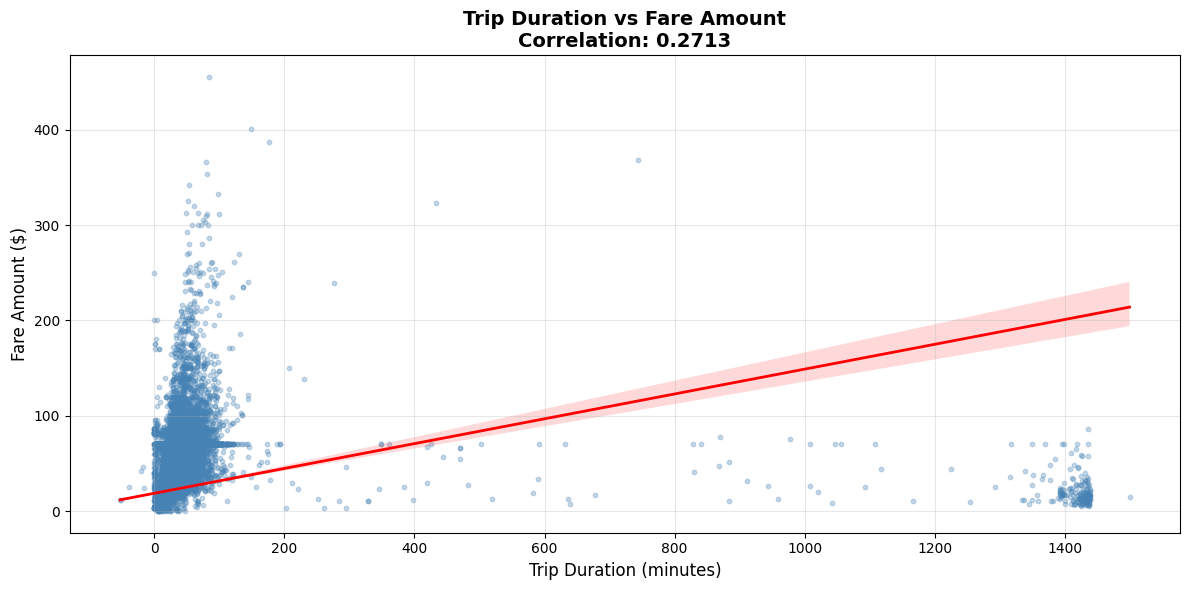

In [150]:
# Show relationship between fare and trip duration

# Calculate trip duration in minutes
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
 
# Calculate correlation between fare_amount and trip_duration
correlation_filtered = df['fare_amount'].corr(df['trip_duration'])
 
plt.figure(figsize=(12, 6))
sns.regplot(x='trip_duration', y='fare_amount', data=df,
            scatter_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})  # Disable confidence interval for faster rendering
plt.xlabel('Trip Duration (minutes)', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.title(f'Trip Duration vs Fare Amount\nCorrelation: {correlation_filtered:.4f}', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

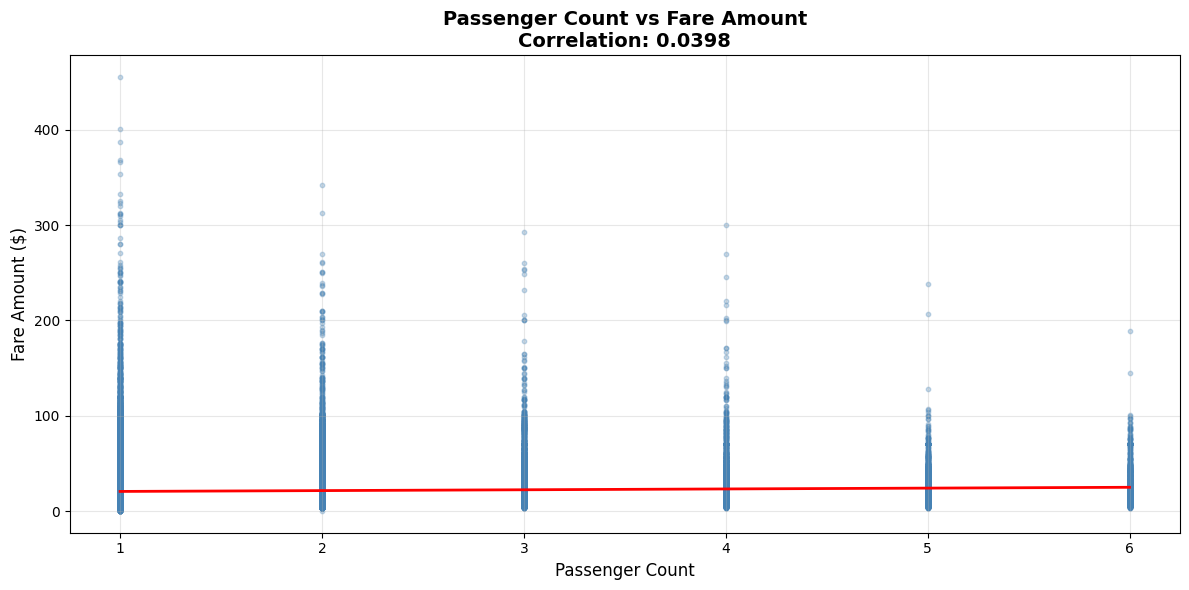

In [151]:
# Show relationship between fare and number of passengers
 
# Calculate correlation between fare_amount and passenger_count
correlation_filtered = df['fare_amount'].corr(df['passenger_count'])
 
plt.figure(figsize=(12, 6))
sns.regplot(x='passenger_count', y='fare_amount', data=df,
            scatter_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.xlabel('Passenger Count', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.title(f'Passenger Count vs Fare Amount\nCorrelation: {correlation_filtered:.4f}', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

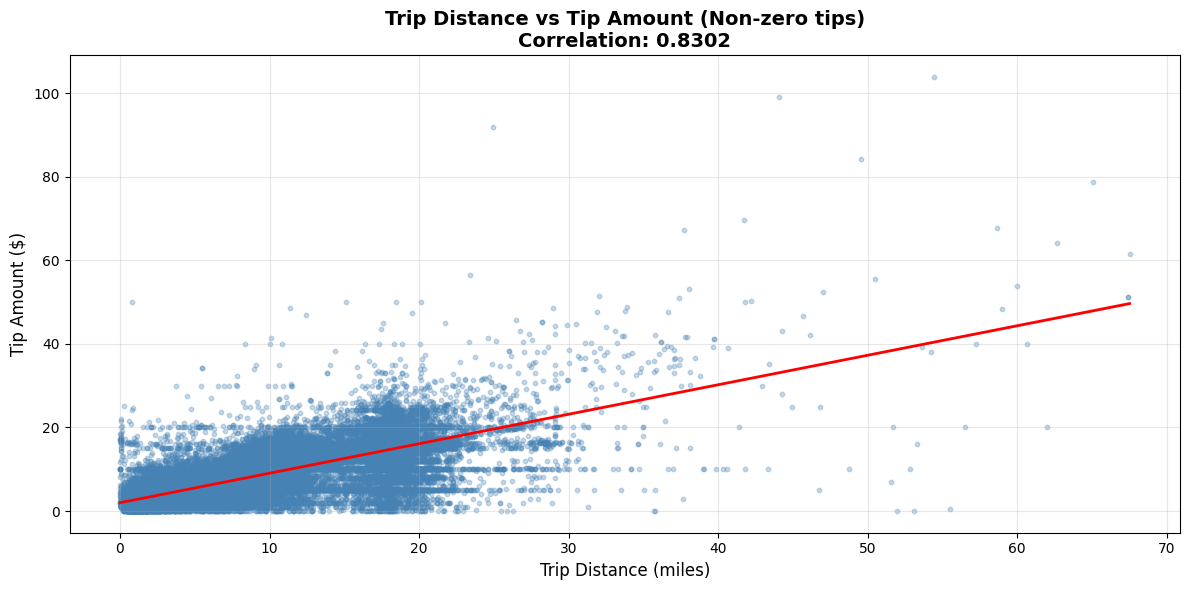

In [ ]:
# Show relationship between tip and trip distance

df_non_zero_tips = df[df['tip_amount'] > 0]
 
correlation_filtered = df_non_zero_tips['trip_distance'].corr(df_non_zero_tips['tip_amount'])
 
plt.figure(figsize=(12, 6))
sns.regplot(x='trip_distance', y='tip_amount', data=df_non_zero_tips,
            scatter_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Tip Amount ($)', fontsize=12)
plt.title(f'Trip Distance vs Tip Amount (Non-zero tips)\nCorrelation: {correlation_filtered:.4f}', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

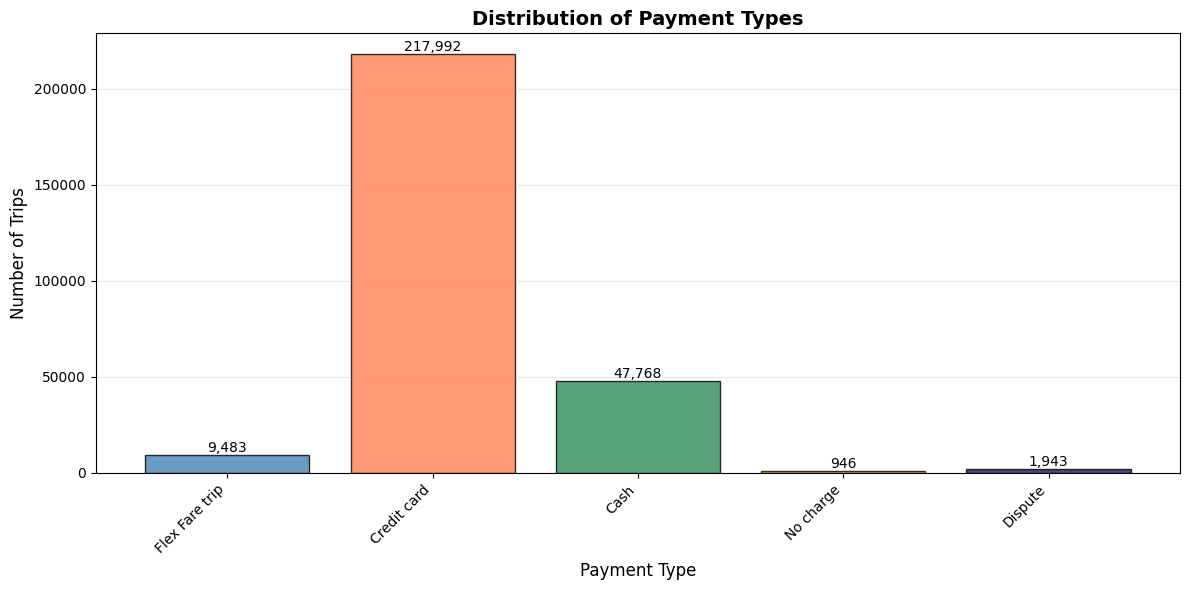

In [155]:
# Analyse the distribution of different payment types (payment_type).
payment_mapping = {
    0: 'Flex Fare trip',
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}
 
# Count of each payment type
payment_counts = df['payment_type'].value_counts().sort_index()
 
# Define colors
colors = ['steelblue', 'coral', 'seagreen', 'orange', 'midnightblue', 'crimson']
 
# Create the count plot
plt.figure(figsize=(12, 6))
bars = plt.bar(payment_counts.index, payment_counts.values, 
               color=[colors[i] for i in payment_counts.index], 
               edgecolor='black', alpha=0.8)
 
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.title('Distribution of Payment Types', fontsize=14, fontweight='bold')
plt.xticks(payment_counts.index, [payment_mapping[i] for i in payment_counts.index], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
 
# Add value labels on top of bars
for i, (idx, val) in enumerate(payment_counts.items()):
    plt.text(idx, val, f'{val:,}', ha='center', va='bottom', fontsize=10)
 
plt.tight_layout()
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [156]:
!pip3 install geopandas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [161]:
import geopandas as gpd

zones = gpd.read_file("taxi_zones/taxi_zones.shp")
zones.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

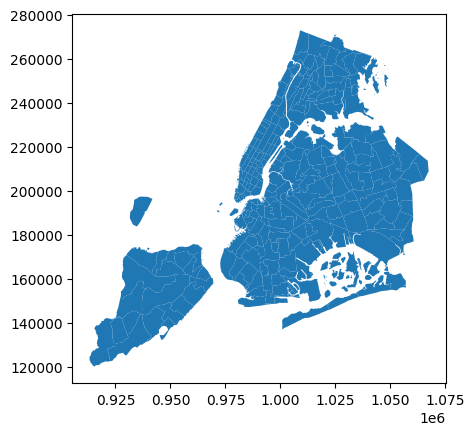

In [165]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [186]:
# Merge zones and trip records using locationID and PULocationID

df_zones = pd.merge(df, zones, left_on='pu_location_id', right_on='LocationID', how='left')



**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [198]:
# Group data by location and calculate the number of trips
pickup_counts =  df_zones.groupby('LocationID').size().reset_index(name='trip_count')
pickup_counts

,LocationID,trip_count
0,1.0,1
1,3.0,5
2,4.0,425
3,5.0,1
4,6.0,1
...,...,...
229,259.0,9
230,260.0,71
231,261.0,1351
232,262.0,3893


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [199]:
# Merge trip counts back to the zones GeoDataFrame


# Merge pickup counts to zones GeoDataFrame
zones = zones.merge(
    pickup_counts,
    on='LocationID',
    how='left'
)
zones


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",5.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",425.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",1.0
...,...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",9.0
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",71.0
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",1351.0
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",3893.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

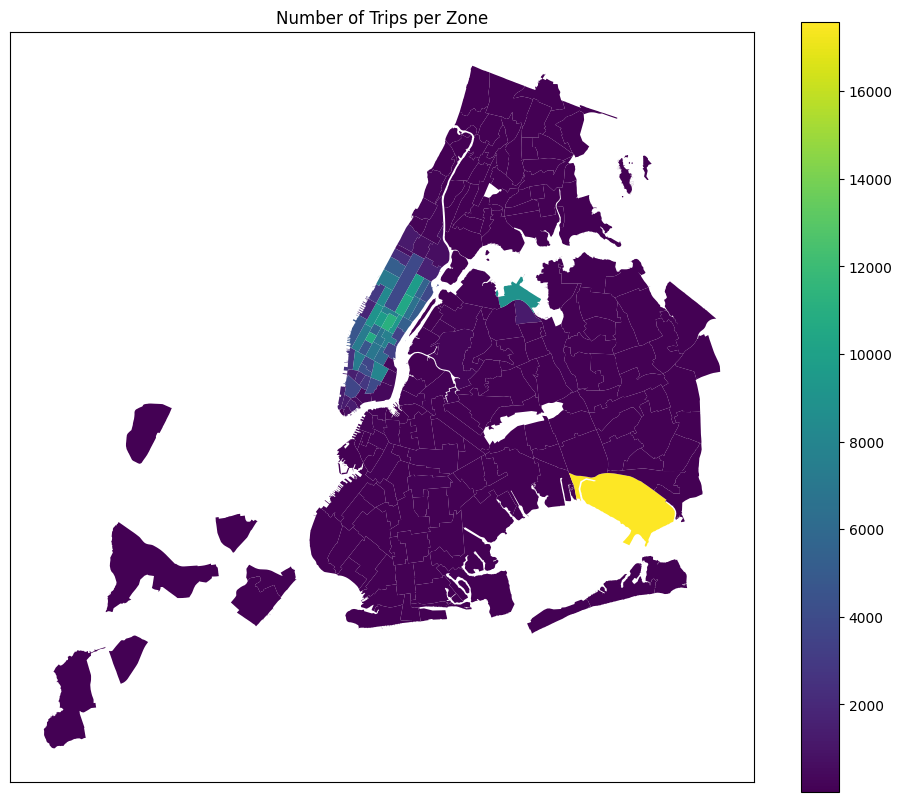

In [484]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
zones.plot(column='trip_count', ax=ax,  legend=True)
plt.title('Number of Trips per Zone')
ax.set_xticks([])
ax.set_yticks([])
plt.show()


In [203]:
# can you try displaying the zones DF sorted by the number of trips?

zones.sort_values(by='trip_count', ascending=False).head(5)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",17577.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",11165.0
185,186,0.024696,0.000037,Penn Station/Madison Sq West,186,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21...",10708.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",10476.0
229,230,0.031028,0.000056,Times Sq/Theatre District,230,Manhattan,"POLYGON ((988786.877 214532.094, 988650.277 21...",9675.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

/var/folders/86/nrdhsxgd7lqcp2nn26r7xx_w0000gp/T/ipykernel_3901/2858953221.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slowest_routes = slowest_routes.groupby('pickup_hour', group_keys=False).apply(


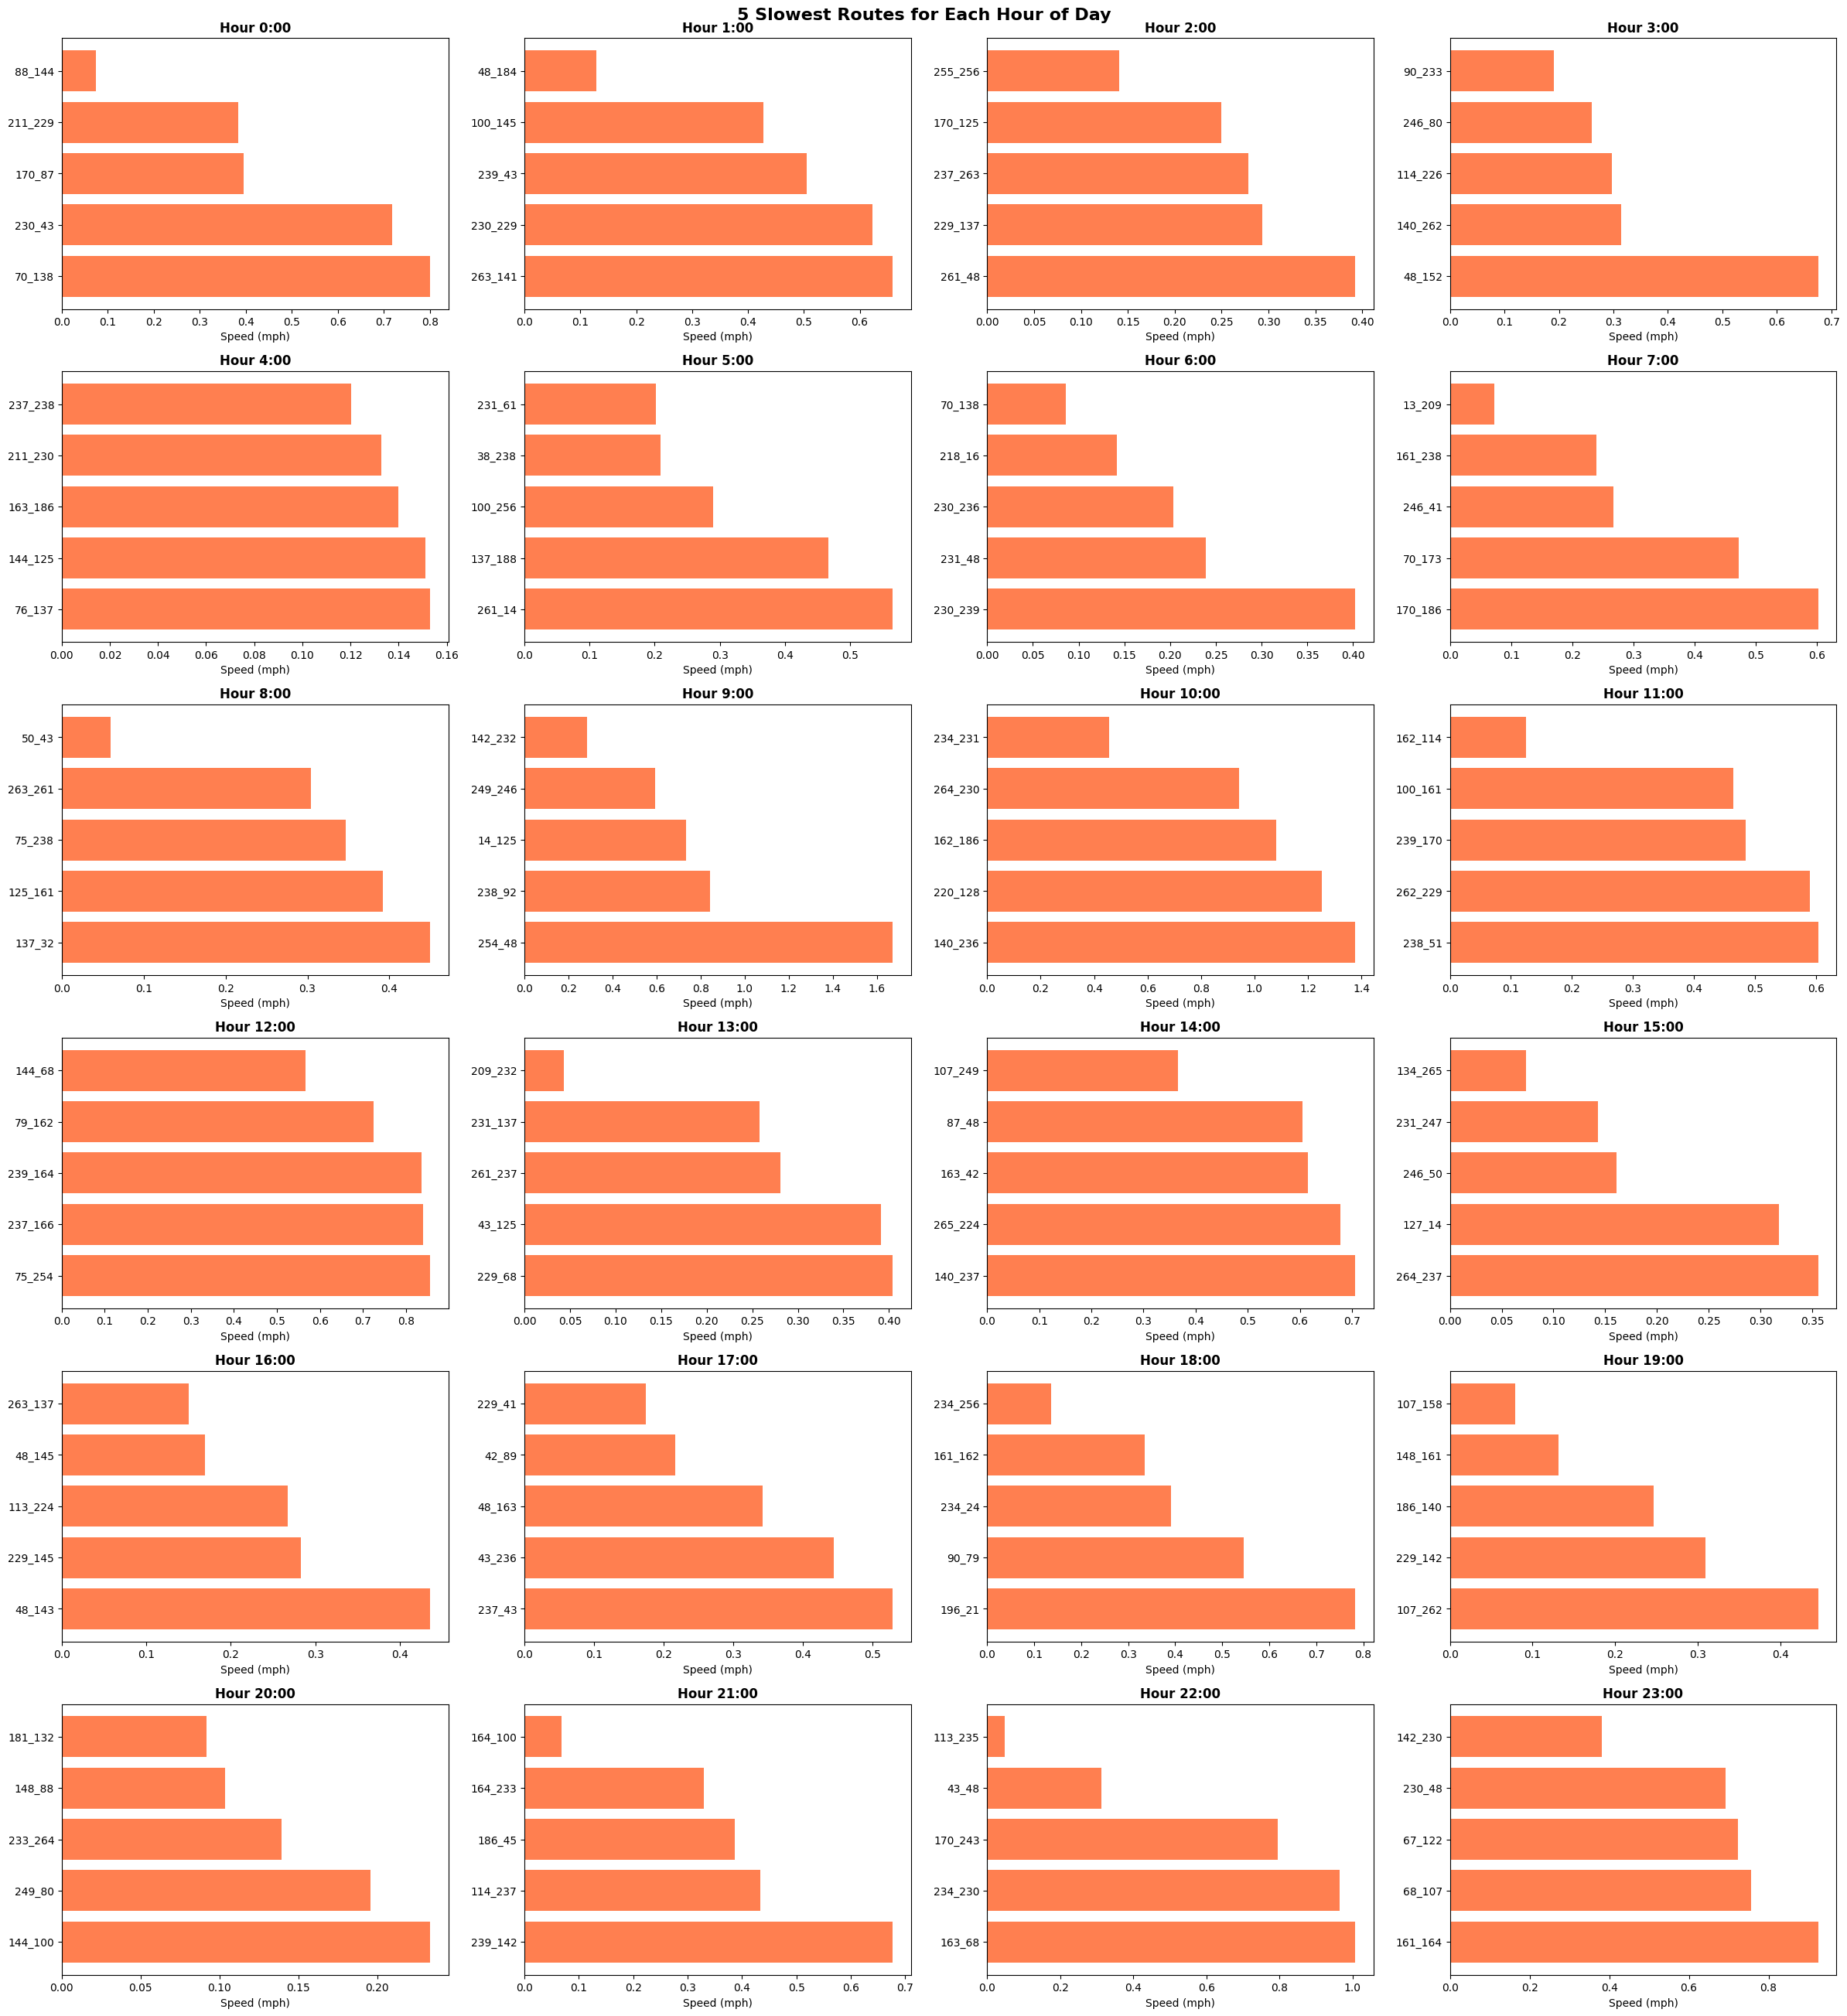

In [ ]:
# Find routes which have the slowest speeds at different times of the day

##Filtering out negative trip_durations
df = df[df['trip_duration'] > 0]

##Converting trip_duration to hours
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 3600

df.columns
##Unikely identifying a route
df['route'] = df['pu_location_id'].astype(str) + '_' + df['do_location_id'].astype(str)

##Grouping by route and pickup hour to calculate average speed of route
route_hour_speed = df.groupby(['route', 'pickup_hour']).agg({
    'trip_distance': 'mean',
    'trip_duration': 'mean'
})

route_hour_speed['avg_speed'] = route_hour_speed['trip_distance'] / route_hour_speed['trip_duration']

slowest_routes = route_hour_speed.reset_index()
slowest_routes = slowest_routes.groupby('pickup_hour', group_keys=False).apply(
    lambda x: x.nsmallest(5, 'avg_speed')
).reset_index(drop=True)
 
# Create visualization
fig, axes = plt.subplots(6, 4, figsize=(24, 26))
axes = axes.flatten()
 
for hour in range(24):
    ax = axes[hour]
    hour_data = slowest_routes[slowest_routes['pickup_hour'] == hour].sort_values('avg_speed')
    
    if len(hour_data) > 0:
        routes = [f"{r[:10]}..." if len(r) > 10 else r for r in hour_data['route'].values]
        speeds = hour_data['avg_speed'].values
        
        bars = ax.barh(routes, speeds, color='coral')
        ax.set_xlabel('Speed (mph)')
        ax.set_title(f'Hour {hour}:00', fontweight='bold')
        ax.invert_yaxis()
        
        ###for i, (bar, speed) in enumerate(zip(bars, speeds)):
        ###    ax.text(speed, i, f' {speed:.2f}', va='center')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Hour {hour}:00')
 
plt.tight_layout()
plt.suptitle('5 Slowest Routes for Each Hour of Day', fontsize=16, fontweight='bold', y=1.001)
plt.show()

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

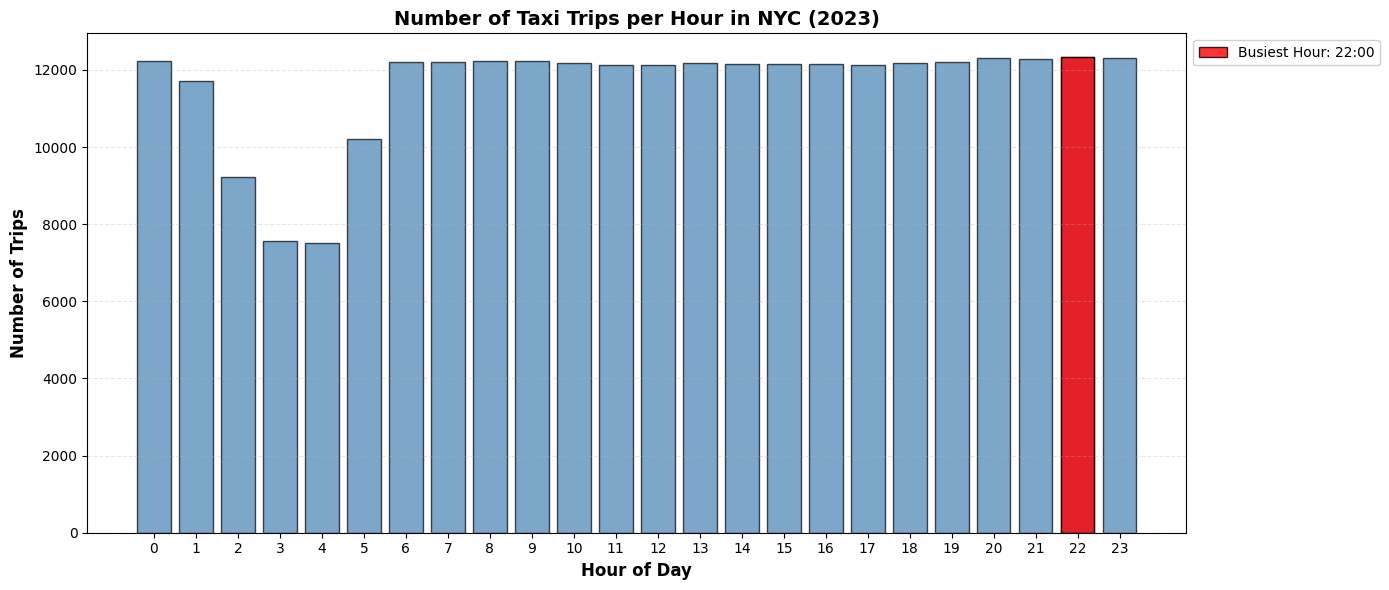

In [262]:
# Visualise the number of trips per hour and find the busiest hour
# Count the number of trips per hour
trips_per_hour = df['pickup_hour'].value_counts().sort_index()
 
# Create the visualization
plt.figure(figsize=(14, 6))
plt.bar(trips_per_hour.index, trips_per_hour.values, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Hour of Day', fontsize=12, fontweight='bold')
plt.ylabel('Number of Trips', fontsize=12, fontweight='bold')
plt.title('Number of Taxi Trips per Hour in NYC (2023)', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3, linestyle='--')
 
# Highlight the busiest hour
busiest_hour = trips_per_hour.idxmax()
busiest_count = trips_per_hour.max()
plt.bar(busiest_hour, busiest_count, color='red', edgecolor='black', alpha=0.8, label=f'Busiest Hour: {busiest_hour}:00')
 
plt.legend(fontsize=10 ,loc='upper left', bbox_to_anchor=(1, 1), framealpha=0.9)
plt.tight_layout()
plt.show()
 

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

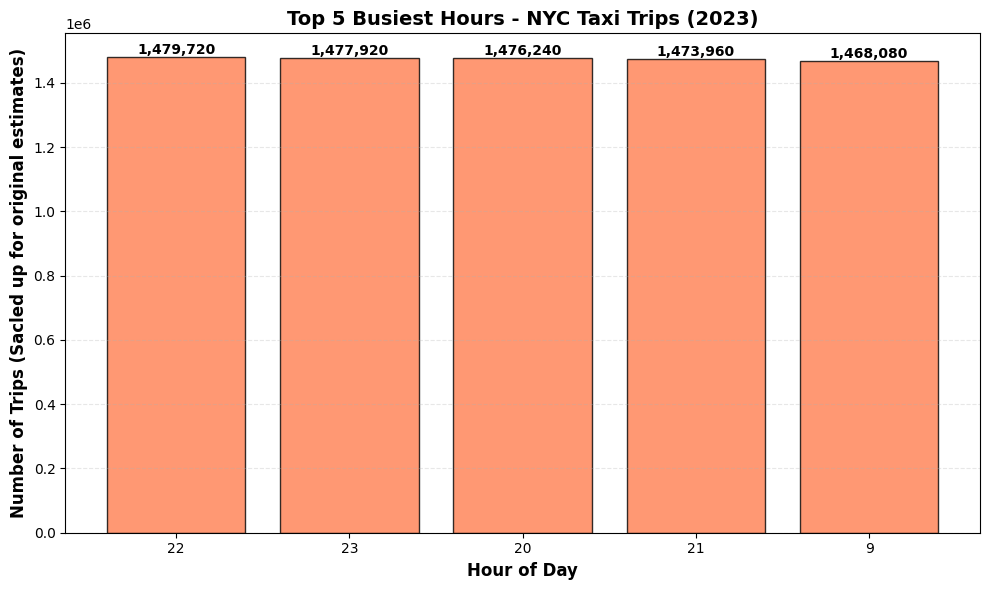

In [271]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
#since the 5% sample were giving 1.8 M records and we further took it down to 300000, this means the original fraction
#is 6 (1.8M/300000) * 20 (1.8M/5%) 
sample_fraction = 120

# slice the top busiest hours based on number of trips
top_5_busiest = trips_per_hour.nlargest(5)
#Scaling up to original numbers
top_5_busiest = top_5_busiest * sample_fraction;

plt.figure(figsize=(10, 6))
plt.bar(top_5_busiest.index.astype(str), top_5_busiest.values, color='coral', edgecolor='black', alpha=0.8)
plt.xlabel('Hour of Day', fontsize=12, fontweight='bold')
plt.ylabel('Number of Trips (Sacled up for original estimates)', fontsize=12, fontweight='bold')
plt.title('Top 5 Busiest Hours - NYC Taxi Trips (2023)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
 
# Add value labels on top of bars
for i, (hour, count) in enumerate(zip(top_5_busiest.index, top_5_busiest.values)):
    plt.text(i, count + 100, f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
 
plt.tight_layout()
plt.show()

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

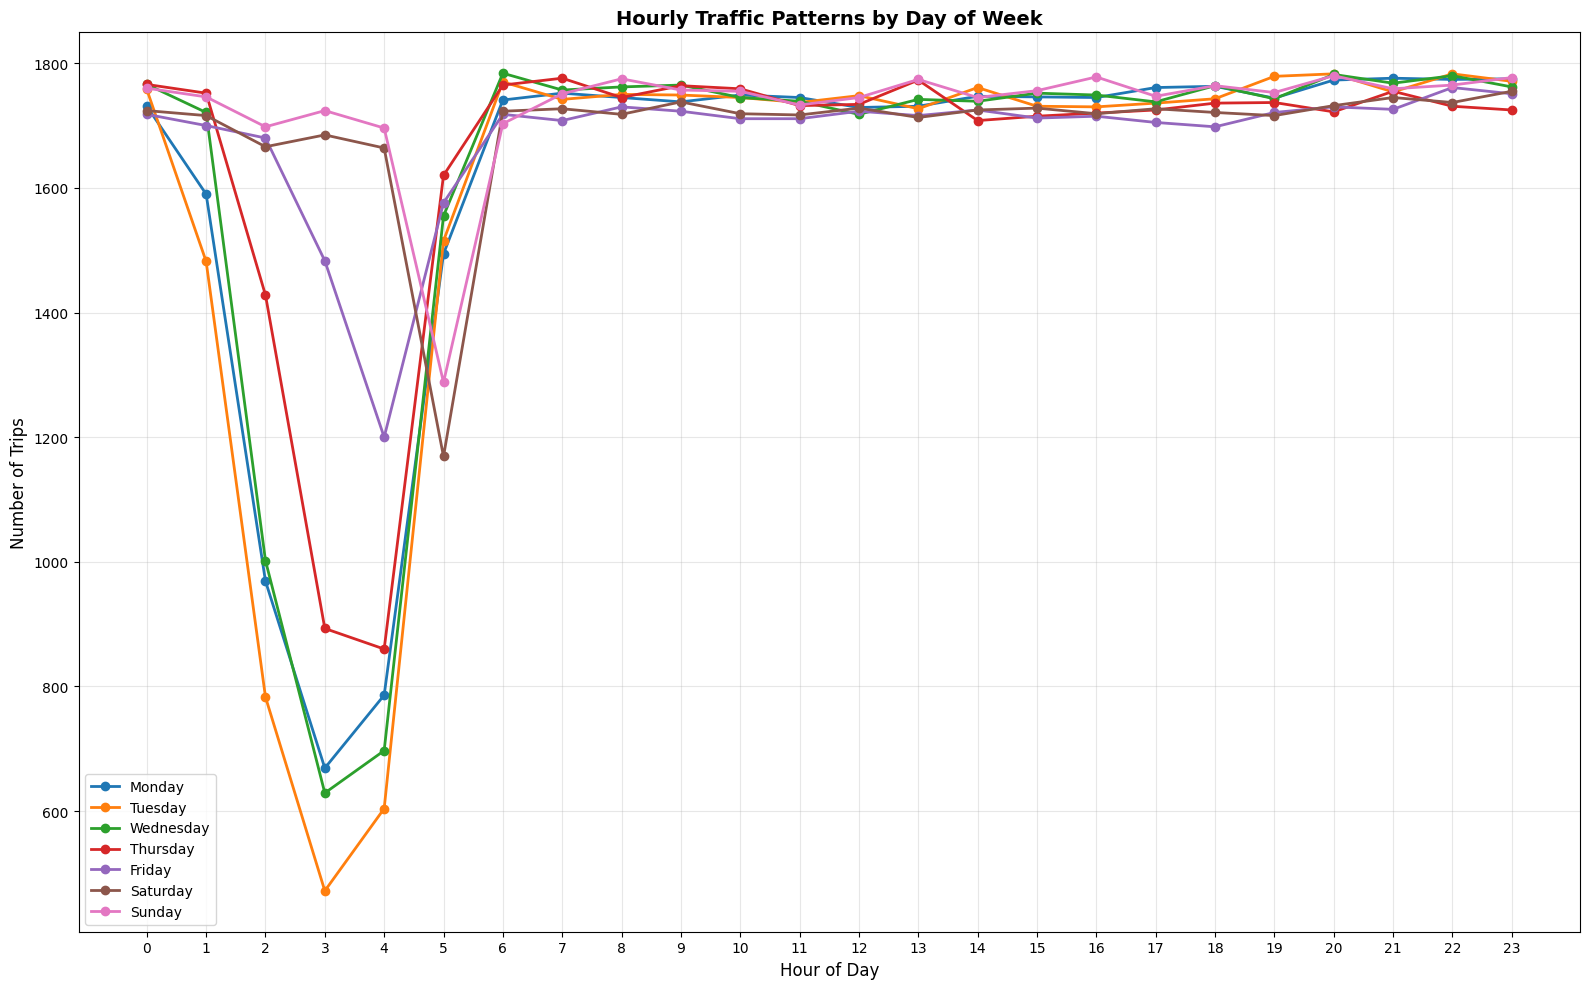

In [289]:
# Compare traffic trends for the week days and weekends


# Prepare the data
hourly_by_day = df.groupby(['pickup_day_of_week', 'pickup_hour']).agg({'pu_location_id': 'count'}).reset_index()
hourly_by_day.columns = ['day', 'hour', 'trip_count']
 
# Create line plot
plt.figure(figsize=(16, 10))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
 
for day in days_order:
    day_data = hourly_by_day[hourly_by_day['day'] == day]
    plt.plot(day_data['hour'], day_data['trip_count'], marker='o', label=day, linewidth=2)
 
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.title('Hourly Traffic Patterns by Day of Week', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

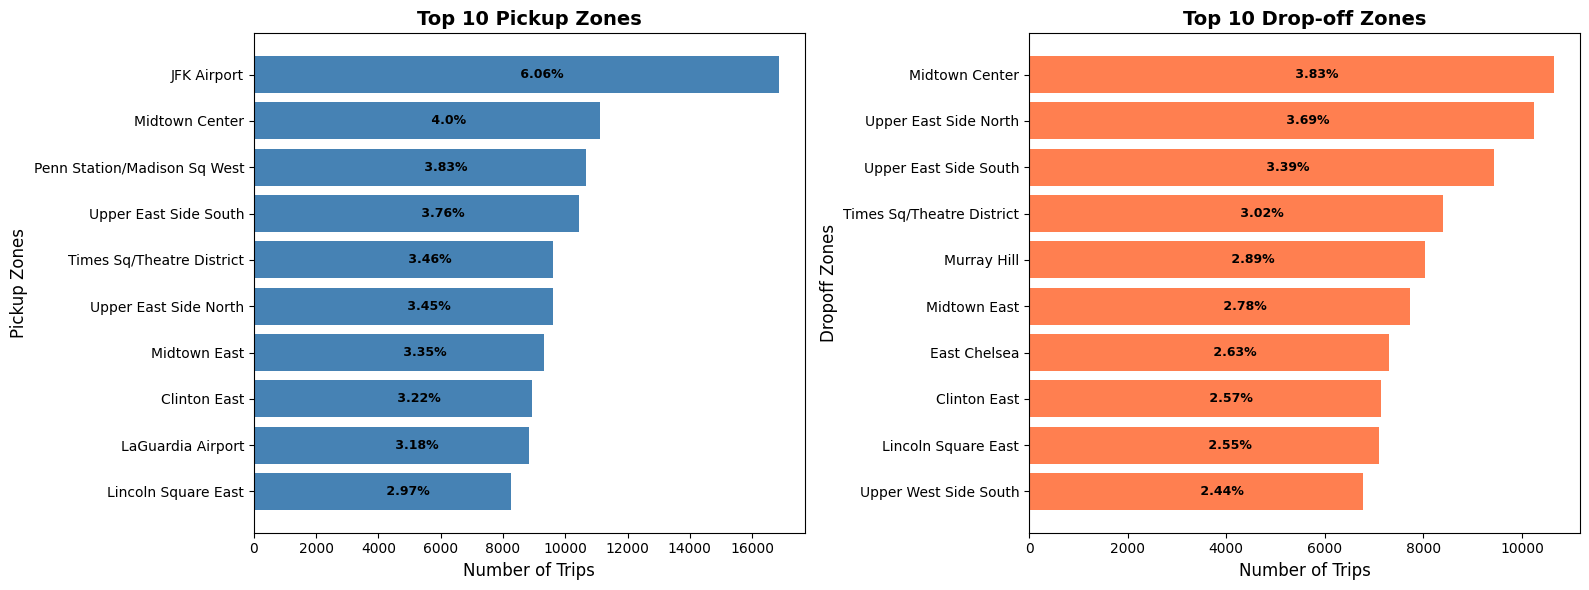

In [ ]:
# Find top 10 pickup and dropoff zones
#merge zone names from zones to the data frame
df_merged_zone_names = pd.merge(df, zones[['LocationID','zone']].rename(columns={'LocationID':'pu_location_id','zone':'pickup_zone'}), left_on='pu_location_id', right_on='pu_location_id')

df_merged_zone_names = pd.merge(df_merged_zone_names, zones[['LocationID','zone']].rename(columns={'LocationID':'do_location_id','zone':'dropoff_zone'}), left_on='do_location_id', right_on='do_location_id')
 
# Get top 10 pickup zones
top_pickup = df_merged_zone_names['pickup_zone'].value_counts().head(10)
 
# Get top 10 drop-off zones
top_dropoff = df_merged_zone_names['dropoff_zone'].value_counts().head(10)
ig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Calculate percentages
total_trips = len(df_merged_zone_names)

top_pickup_pct = (top_pickup / total_trips * 100).round(2)
top_dropoff_pct = (top_dropoff / total_trips * 100).round(2)
 
# Pickup zones with percentages
bars1 = axes[0].barh(range(len(top_pickup)), top_pickup.values, color='steelblue')
axes[0].set_yticks(range(len(top_pickup)))
axes[0].set_yticklabels([f'{id}' for id in top_pickup.index])
axes[0].set_xlabel('Number of Trips', fontsize=12)
axes[0].set_ylabel('Pickup Zones', fontsize=12)
axes[0].set_title('Top 10 Pickup Zones', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
 
# Add percentage labels
for i, (bar, pct) in enumerate(zip(bars1, top_pickup_pct)):
    axes[0].text(bar.get_width()/2, bar.get_y() + bar.get_height()/2, 
                 f' {pct}%', va='center', fontsize=9,fontweight='bold')
 
# Drop-off zones with percentages
bars2 = axes[1].barh(range(len(top_dropoff)), top_dropoff.values, color='coral')
axes[1].set_yticks(range(len(top_dropoff)))
axes[1].set_yticklabels([f'{id}' for id in top_dropoff.index])
axes[1].set_xlabel('Number of Trips', fontsize=12)
axes[1].set_ylabel('Dropoff Zones', fontsize=12)
axes[1].set_title('Top 10 Drop-off Zones', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
 
# Add percentage labels
for i, (bar, pct) in enumerate(zip(bars2, top_dropoff_pct)):
    axes[1].text(bar.get_width()/2, bar.get_y() + bar.get_height()/2, 
                 f' {pct}%', va='center', fontsize=9,fontweight='bold')
 
plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

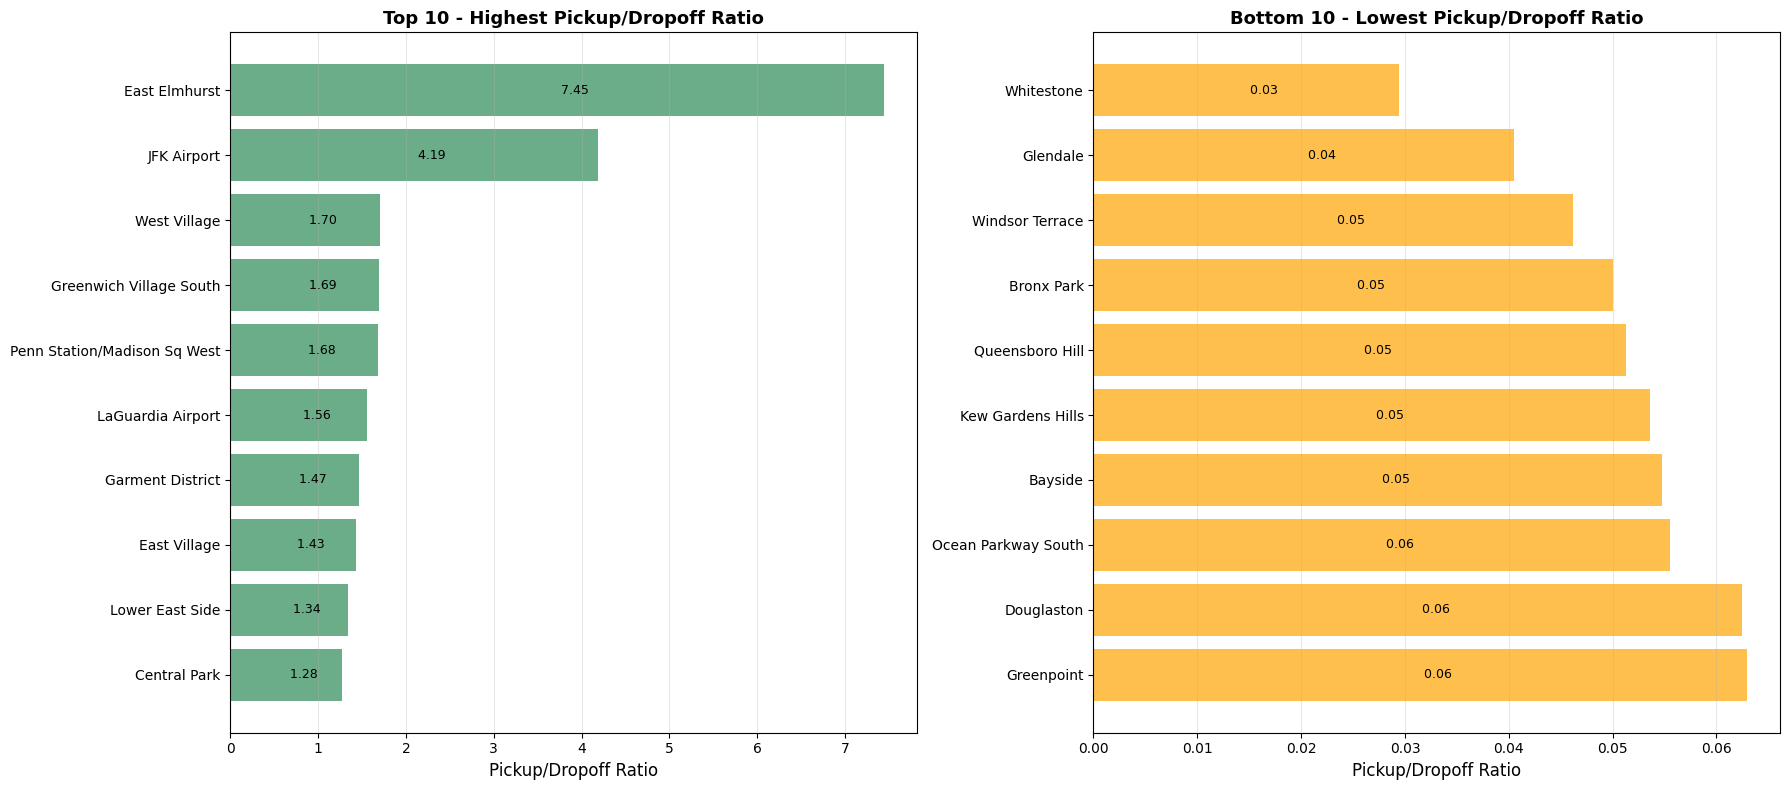

In [340]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
# Count pickups per zone
pickup_counts = df_merged_zone_names['pickup_zone'].value_counts().reset_index()
pickup_counts.columns = ['zone', 'pickup_count']
 
# Count drop-offs per zone
dropoff_counts = df_merged_zone_names['dropoff_zone'].value_counts().reset_index()
dropoff_counts.columns = ['zone', 'dropoff_count']
 
# Merge both counts into a single dataframe
zone_traffic = pickup_counts.merge(dropoff_counts, on='zone', how='inner').fillna(0)
 
zone_traffic['pickup_dropoff_ratio'] = zone_traffic['pickup_count'] / zone_traffic['dropoff_count']

top_10_pickup_dropoff_ratio = zone_traffic.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)
bottom_10_pickup_dropoff_ratio = zone_traffic.sort_values(by='pickup_dropoff_ratio', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
 
# Top 10
bars1 = axes[0].barh(range(len(top_10_pickup_dropoff_ratio)), 
                     top_10_pickup_dropoff_ratio['pickup_dropoff_ratio'].values, 
                     color='seagreen', alpha=0.7)
axes[0].set_yticks(range(len(top_10_pickup_dropoff_ratio)))
axes[0].set_yticklabels(top_10_pickup_dropoff_ratio['zone'].values, fontsize=10)
axes[0].set_xlabel('Pickup/Dropoff Ratio', fontsize=12)
axes[0].set_title('Top 10 - Highest Pickup/Dropoff Ratio', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
 
# Add value labels
for i, (bar, val) in enumerate(zip(bars1, top_10_pickup_dropoff_ratio['pickup_dropoff_ratio'].values)):
    axes[0].text(bar.get_width()/2, bar.get_y() + bar.get_height()/2, 
                 f' {val:.2f}', va='center', fontsize=9)
 
# Bottom 10
bars2 = axes[1].barh(range(len(bottom_10_pickup_dropoff_ratio)), 
                     bottom_10_pickup_dropoff_ratio['pickup_dropoff_ratio'].values, 
                     color='orange', alpha=0.7)
axes[1].set_yticks(range(len(bottom_10_pickup_dropoff_ratio)))
axes[1].set_yticklabels(bottom_10_pickup_dropoff_ratio['zone'].values, fontsize=10)
axes[1].set_xlabel('Pickup/Dropoff Ratio', fontsize=12)
axes[1].set_title('Bottom 10 - Lowest Pickup/Dropoff Ratio', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)
 
# Add value labels
for i, (bar, val) in enumerate(zip(bars2, bottom_10_pickup_dropoff_ratio['pickup_dropoff_ratio'].values)):
    axes[1].text(bar.get_width()/2, bar.get_y() + bar.get_height()/2, 
                 f' {val:.2f}', va='center', fontsize=9)
 
plt.tight_layout()
plt.show()



**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

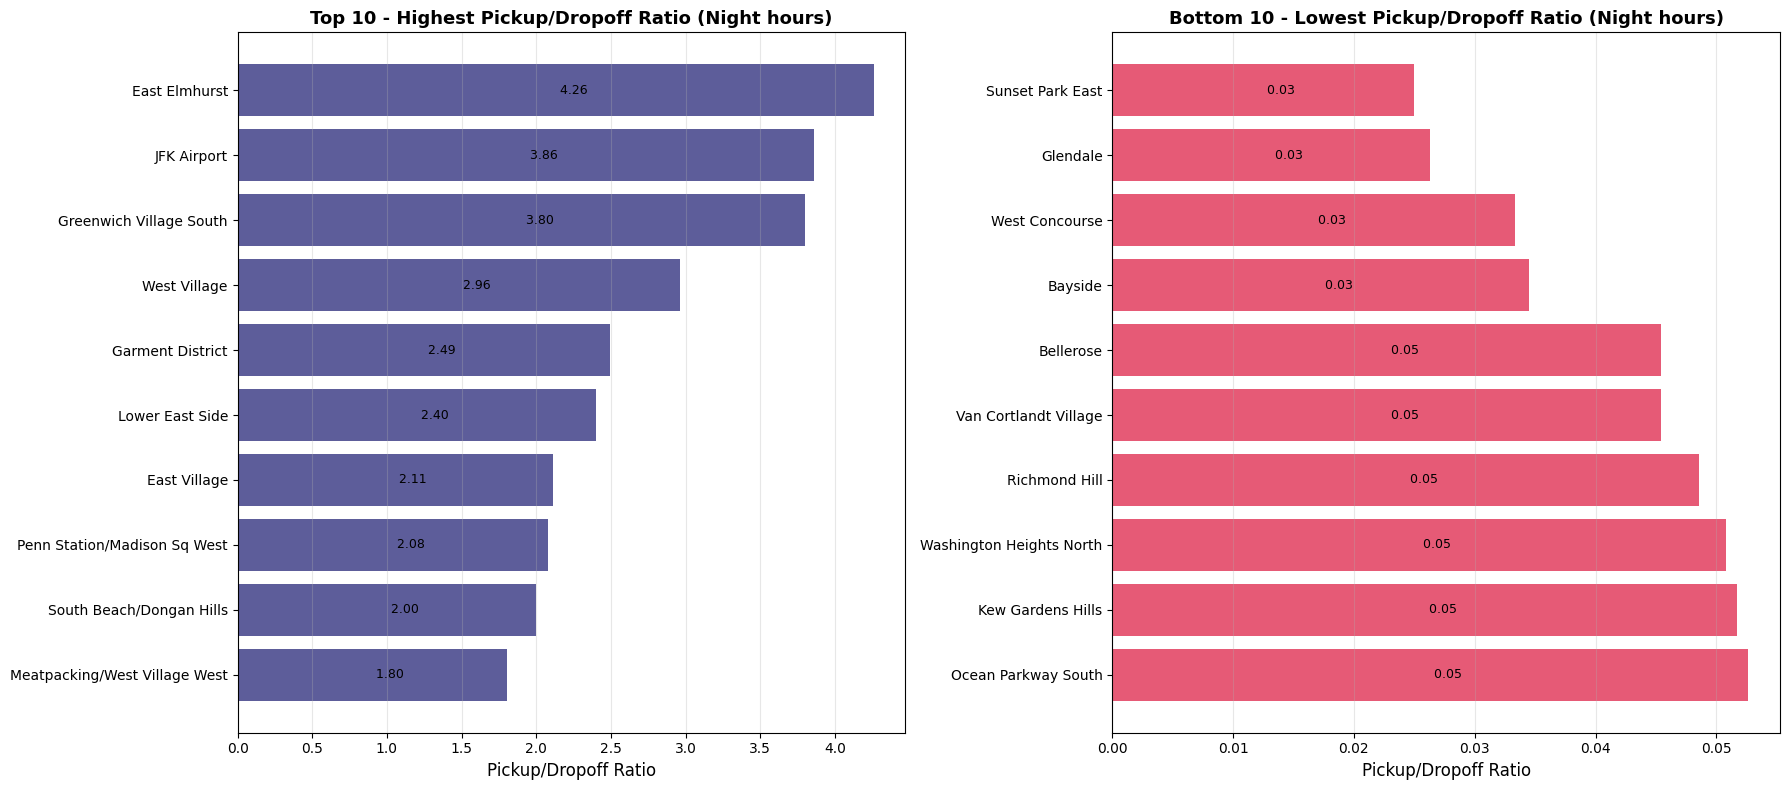

In [344]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

##filtering trips only for night hours
df_merged_zone_names_night = df_merged_zone_names[(df_merged_zone_names['pickup_hour'] >= 23) | (df_merged_zone_names['pickup_hour'] <= 5)]

# Count pickups per zone
pickup_counts = df_merged_zone_names_night['pickup_zone'].value_counts().reset_index()
pickup_counts.columns = ['zone', 'pickup_count']
 
# Count drop-offs per zone
dropoff_counts = df_merged_zone_names_night['dropoff_zone'].value_counts().reset_index()
dropoff_counts.columns = ['zone', 'dropoff_count']
 
# Merge both counts into a single dataframe
zone_traffic = pickup_counts.merge(dropoff_counts, on='zone', how='inner').fillna(0)
 
zone_traffic['pickup_dropoff_ratio'] = zone_traffic['pickup_count'] / zone_traffic['dropoff_count']

top_10_pickup_dropoff_ratio = zone_traffic.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)
bottom_10_pickup_dropoff_ratio = zone_traffic.sort_values(by='pickup_dropoff_ratio', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
 
# Top 10
bars1 = axes[0].barh(range(len(top_10_pickup_dropoff_ratio)), 
                     top_10_pickup_dropoff_ratio['pickup_dropoff_ratio'].values, 
                     color='midnightblue', alpha=0.7)
axes[0].set_yticks(range(len(top_10_pickup_dropoff_ratio)))
axes[0].set_yticklabels(top_10_pickup_dropoff_ratio['zone'].values, fontsize=10)
axes[0].set_xlabel('Pickup/Dropoff Ratio', fontsize=12)
axes[0].set_title('Top 10 - Highest Pickup/Dropoff Ratio (Night hours)', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
 
# Add value labels
for i, (bar, val) in enumerate(zip(bars1, top_10_pickup_dropoff_ratio['pickup_dropoff_ratio'].values)):
    axes[0].text(bar.get_width()/2, bar.get_y() + bar.get_height()/2, 
                 f' {val:.2f}', va='center', fontsize=9)
 
# Bottom 10
bars2 = axes[1].barh(range(len(bottom_10_pickup_dropoff_ratio)), 
                     bottom_10_pickup_dropoff_ratio['pickup_dropoff_ratio'].values, 
                     color='crimson', alpha=0.7)
axes[1].set_yticks(range(len(bottom_10_pickup_dropoff_ratio)))
axes[1].set_yticklabels(bottom_10_pickup_dropoff_ratio['zone'].values, fontsize=10)
axes[1].set_xlabel('Pickup/Dropoff Ratio', fontsize=12)
axes[1].set_title('Bottom 10 - Lowest Pickup/Dropoff Ratio (Night hours)', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)
 
# Add value labels
for i, (bar, val) in enumerate(zip(bars2, bottom_10_pickup_dropoff_ratio['pickup_dropoff_ratio'].values)):
    axes[1].text(bar.get_width()/2, bar.get_y() + bar.get_height()/2, 
                 f' {val:.2f}', va='center', fontsize=9)
 
plt.tight_layout()
plt.show()

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

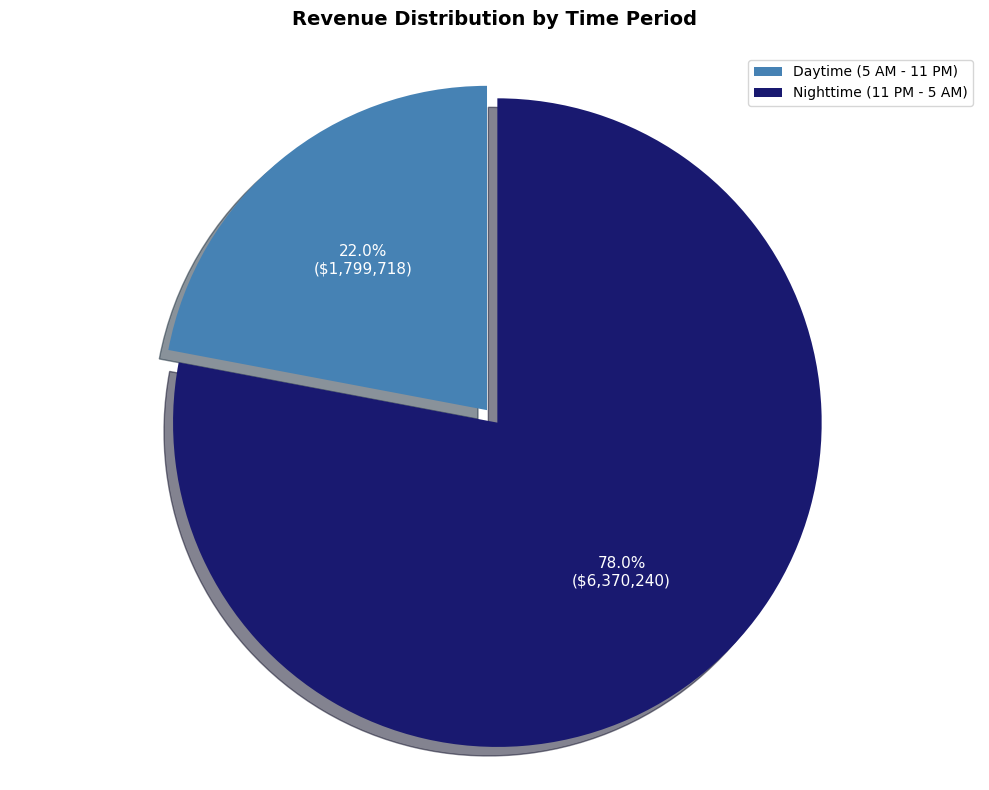

In [496]:
# Filter for night hours (11 PM to 5 AM)

# Define daytime (6 AM to 6 PM) and nighttime (6 PM to 6 AM)
df_merged_zone_names['time_period'] = df_merged_zone_names['pickup_hour'].apply(
    lambda x: 'Daytime (5 AM - 11 PM)' if (x >= 23 or x < 5) else 'Nighttime (11 PM - 5 AM)'
)
 
# Calculate revenue by time period
revenue_by_time = df_merged_zone_names.groupby('time_period').agg({
    'total_amount': 'sum',
    'pu_location_id': 'count'  # trip count
}).reset_index()
 
revenue_by_time.columns = ['time_period', 'total_revenue', 'trip_count']
 
plt.figure(figsize=(10, 8))
 
colors = ['steelblue', 'midnightblue']
explode = (0.05, 0)
 
# Create labels with both percentage and dollar amounts
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n(${val:,.0f})'
    return my_autopct
 
plt.pie(revenue_by_time['total_revenue'], 
        labels=revenue_by_time['time_period'],
        autopct=make_autopct(revenue_by_time['total_revenue']),
        colors=colors,
        explode=explode,
        startangle=90,
        textprops={'fontsize': 11,'color':'white'},
        shadow=True)
 
plt.title('Revenue Distribution by Time Period', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.legend(revenue_by_time['time_period'], loc='best')
plt.show()


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

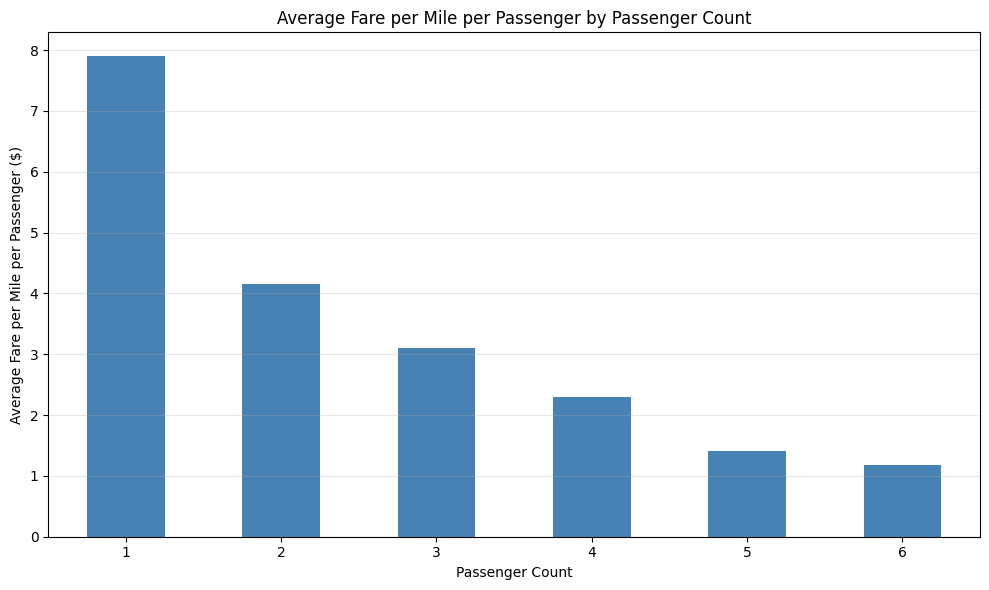

In [350]:
# Analyse the fare per mile per passenger for different passenger counts

# Filter out trips with zero distance to avoid division by zero
df_valid = df[(df['trip_distance'] > 0) & (df['passenger_count'] > 0)]
 
# Calculate fare per mile per passenger
df_valid['fare_per_mile_per_passenger'] = df_valid['fare_amount'] / (df_valid['trip_distance'] * df_valid['passenger_count'])
 
# Group by passenger count and calculate average
avg_fare_per_mile_per_passenger = df_valid.groupby('passenger_count')['fare_per_mile_per_passenger'].mean()
 
# Visualize the results
plt.figure(figsize=(10, 6))
avg_fare_per_mile_per_passenger.sort_index().plot(kind='bar', color='steelblue')
plt.xlabel('Passenger Count')
plt.ylabel('Average Fare per Mile per Passenger ($)')
plt.title('Average Fare per Mile per Passenger by Passenger Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

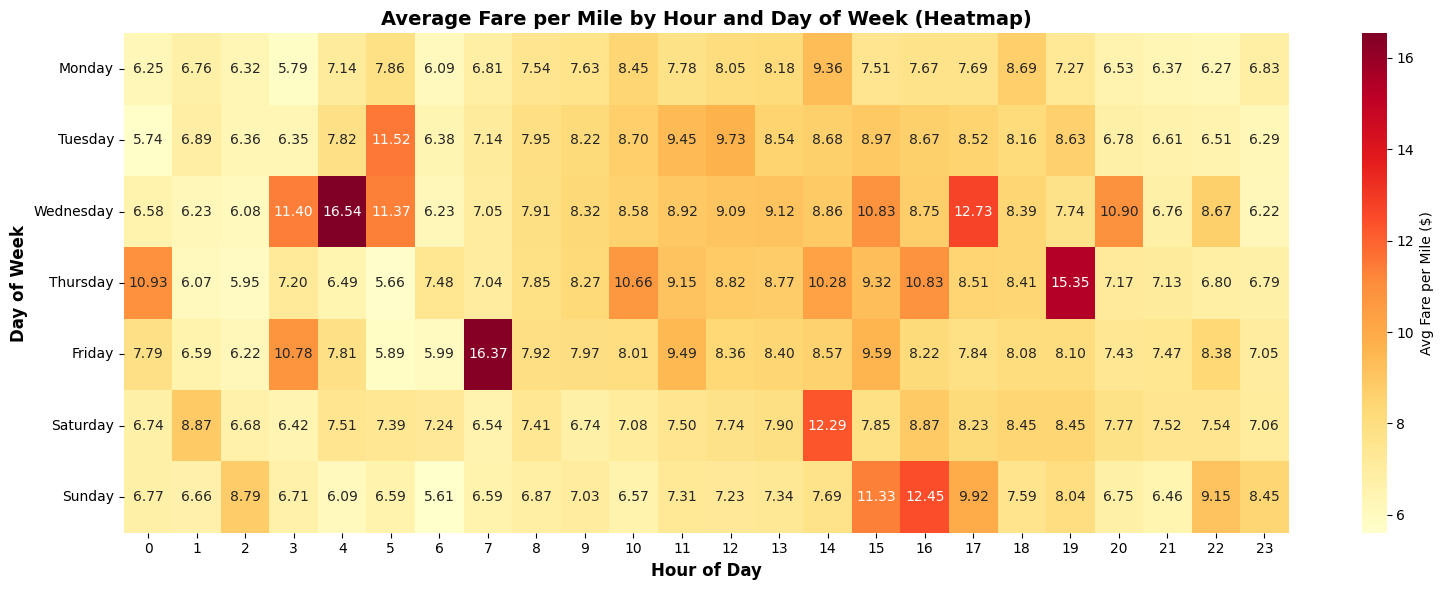

In [360]:
# Compare the average fare per mile for different days and for different times of the day

# Calculate fare per mile (excluding trips with zero distance to avoid division by zero)
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']
 

# Calculate average fare per mile by hour and day of week
avg_fare_per_mile = df.groupby(['pickup_hour', 'pickup_day_of_week'])['fare_per_mile'].mean().reset_index()
 
# Create a pivot table for better visualization
pivot_data = avg_fare_per_mile.pivot(index='pickup_day_of_week', 
                                       columns='pickup_hour', 
                                       values='fare_per_mile')
 
# Reorder days of week properly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_data = pivot_data.reindex(day_order)
 
# Create heatmap
plt.figure(figsize=(16, 6))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Avg Fare per Mile ($)'})
plt.xlabel('Hour of Day', fontsize=12, fontweight='bold')
plt.ylabel('Day of Week', fontsize=12, fontweight='bold')
plt.title('Average Fare per Mile by Hour and Day of Week (Heatmap)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

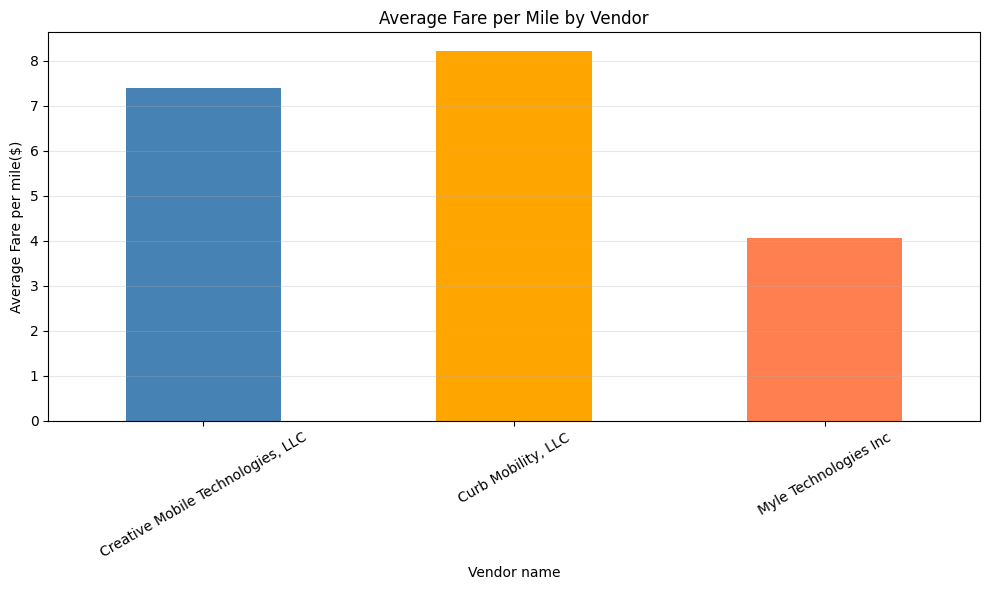

In [398]:
# Compare fare per mile for different vendors

vendor_mapping = {
    1: 'Creative Mobile Technologies, LLC',
    2: 'Curb Mobility, LLC',
    6: 'Myle Technologies Inc'
}

# Calculate average fare per mile by vendor_id
avg_fare_by_vendor = df.groupby('vendor_id')['fare_per_mile'].mean()
avg_fare_by_vendor.index = avg_fare_by_vendor.index.map(vendor_mapping)
plt.figure(figsize=(10, 6))
avg_fare_by_vendor.plot(kind='bar', color=['steelblue', 'orange','coral'])
plt.xlabel('Vendor name')
plt.ylabel('Average Fare per mile($)')
plt.title('Average Fare per Mile by Vendor')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


/var/folders/86/nrdhsxgd7lqcp2nn26r7xx_w0000gp/T/ipykernel_3901/3620128169.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_fare_by_distance_category = df.groupby(['vendor_id','distance_category'])['fare_per_mile'].mean()


<Figure size 1400x800 with 0 Axes>

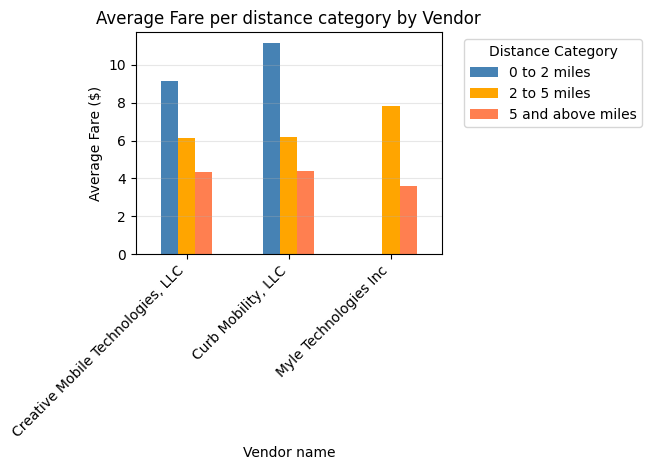

In [404]:
# Defining distance tiers

df['distance_category'] = pd.cut(
    df['trip_distance'],
    bins=[0, 2, 5, float('inf')],
    labels=['0 to 2 miles', '2 to 5 miles', '5 and above miles'],
    include_lowest=True
)

avg_fare_by_distance_category = df.groupby(['vendor_id','distance_category'])['fare_per_mile'].mean()
avg_fare_by_distance_category.index = avg_fare_by_distance_category.index.set_levels(
    avg_fare_by_distance_category.index.levels[0].map(vendor_mapping),
    level=0
)

plt.figure(figsize=(14, 8))
avg_fare_by_distance_category.unstack().plot(kind='bar', color=['steelblue', 'orange','coral'])
plt.xlabel('Vendor name')
plt.ylabel('Average Fare ($)')
plt.title('Average Fare per distance category by Vendor')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Distance Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

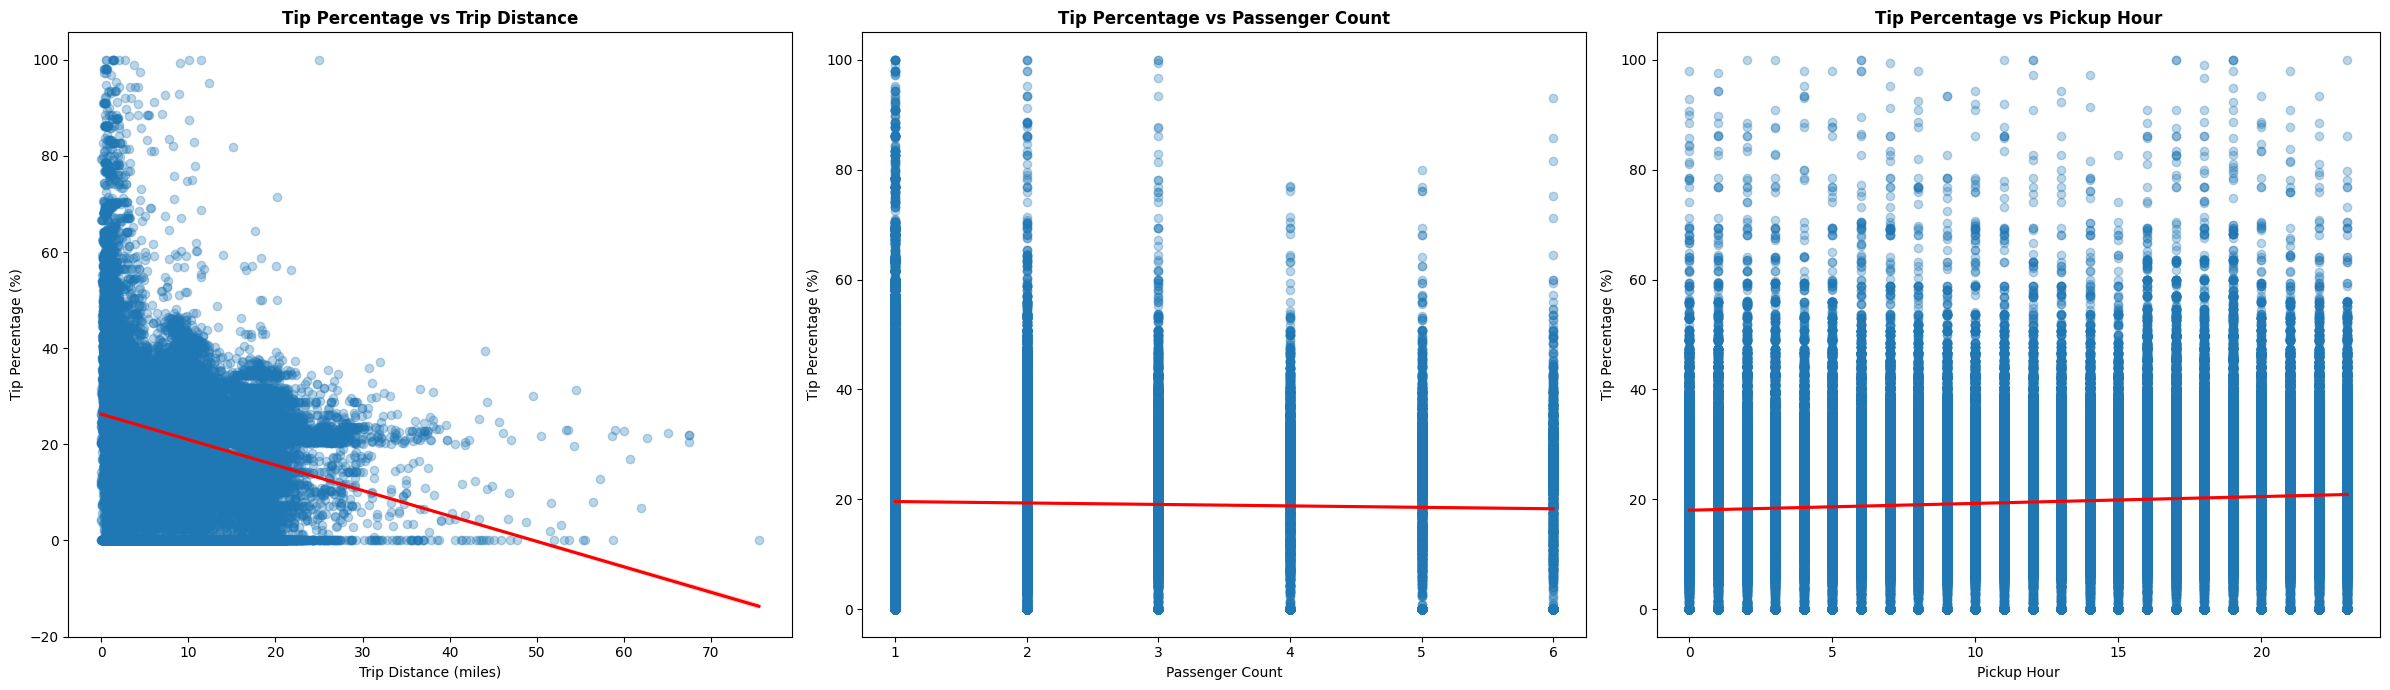

In [412]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df['tip_percentage'] = df['tip_amount'] / df['fare_amount'] * 100

# Filter out cash payments (payment_type == 2) since tips aren't recorded
df_credit = df[df['payment_type'] == 1]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
 
# 1. Regression plot: tip_percentage vs trip_distance
sns.regplot(data=df_credit, x='trip_distance', y='tip_percentage', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'},
            ax=axes[0])
axes[0].set_title('Tip Percentage vs Trip Distance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trip Distance (miles)')
axes[0].set_ylabel('Tip Percentage (%)')
 
# 2. Regression plot: tip_percentage vs passenger_count
sns.regplot(data=df, x='passenger_count', y='tip_percentage', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'},
            ax=axes[1])
axes[1].set_title('Tip Percentage vs Passenger Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Tip Percentage (%)')
 
# 3. Regression plot: tip_percentage vs pickup_hour
sns.regplot(data=df, x='pickup_hour', y='tip_percentage', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'},
            ax=axes[2])
axes[2].set_title('Tip Percentage vs Pickup Hour', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Pickup Hour')
axes[2].set_ylabel('Tip Percentage (%)')
 
plt.tight_layout()
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

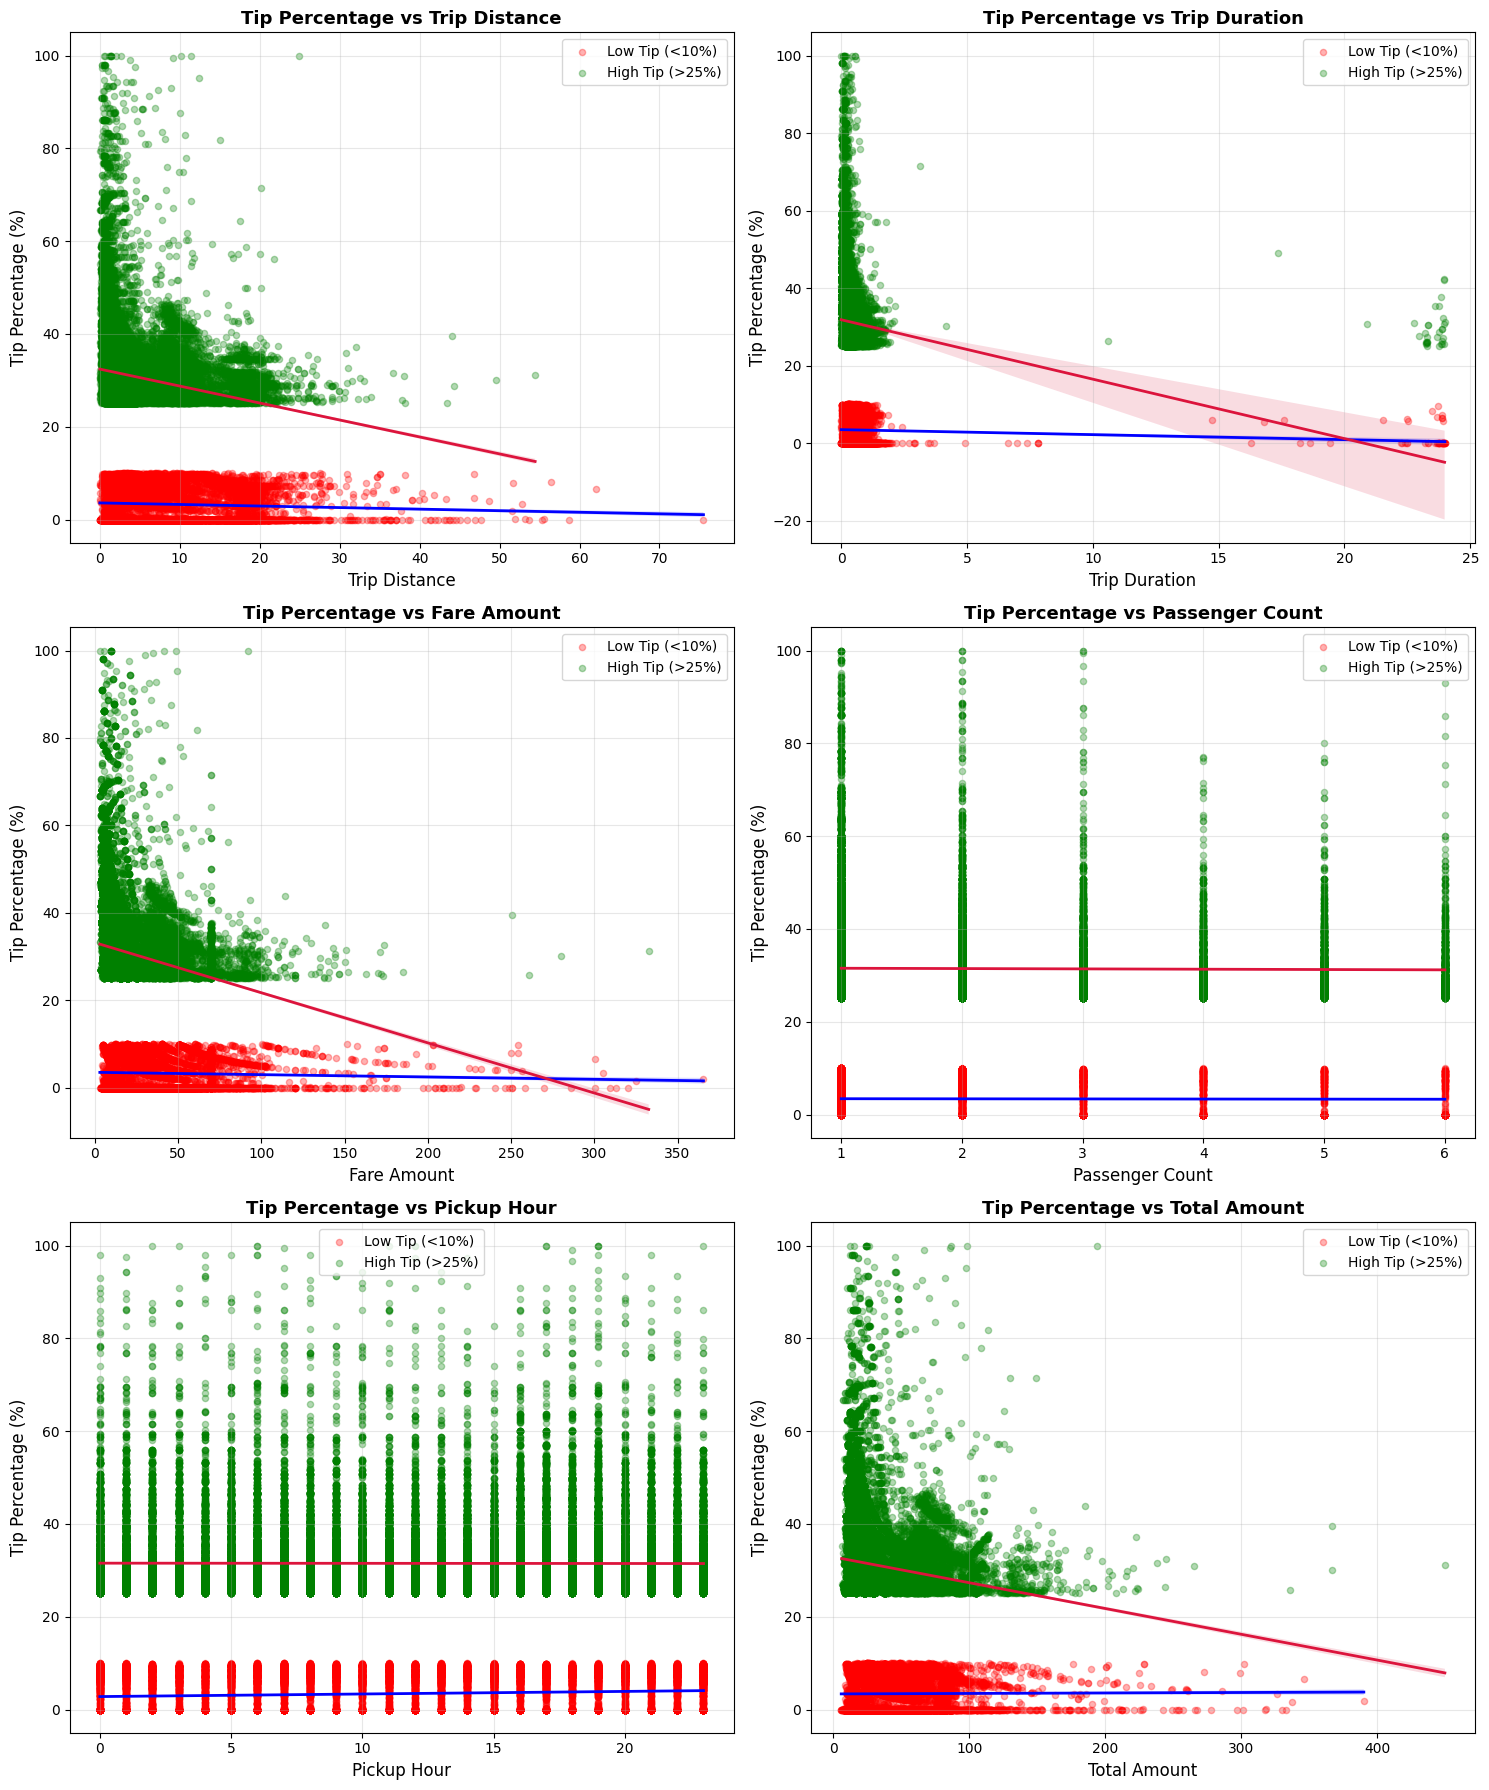

In [417]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

 
# Create comparison groups
low_tip = df_credit[df_credit['tip_percentage'] < 10]
high_tip = df_credit[df_credit['tip_percentage'] > 25]
 
# Compare means/medians
comparison_cols = ['trip_distance', 'trip_duration', 'fare_amount', 
                   'passenger_count', 'pickup_hour', 'total_amount']
 
 # Create regression plots for each variable
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()
 
for idx, col in enumerate(comparison_cols):
    ax = axes[idx]
    
    # Plot low tip group
    sns.regplot(data=low_tip, x=col, y='tip_percentage', 
                scatter_kws={'alpha': 0.3, 's': 20}, 
                line_kws={'color': 'blue', 'linewidth': 2},
                label='Low Tip (<10%)', ax=ax, color='red')
    
    # Plot high tip group
    sns.regplot(data=high_tip, x=col, y='tip_percentage', 
                scatter_kws={'alpha': 0.3, 's': 20}, 
                line_kws={'color': 'crimson', 'linewidth': 2},
                label='High Tip (>25%)', ax=ax, color='green')
    
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel('Tip Percentage (%)', fontsize=12)
    ax.set_title(f'Tip Percentage vs {col.replace("_", " ").title()}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

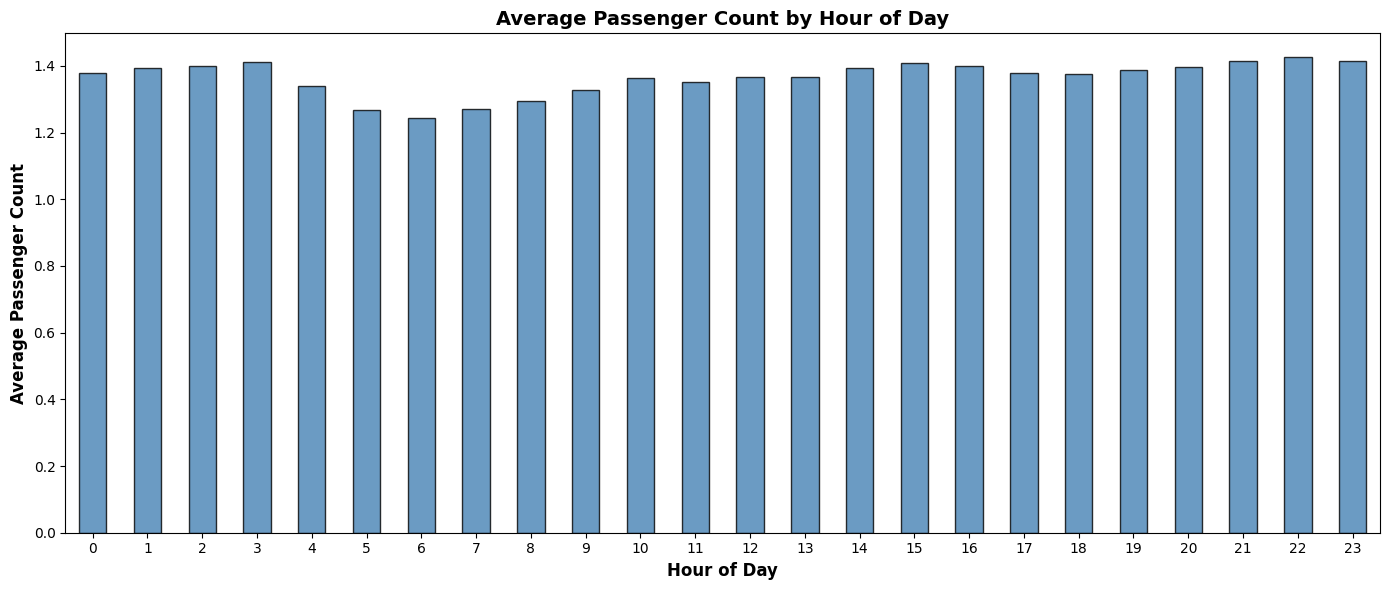

In [427]:
# See how passenger count varies across hours and days

passenger_count_by_hour = df.groupby(['pickup_hour'])['passenger_count'].mean()

# Create visualization
plt.figure(figsize=(14, 6))
passenger_count_by_hour.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Hour of Day', fontsize=12, fontweight='bold')
plt.ylabel('Average Passenger Count', fontsize=12, fontweight='bold')
plt.title('Average Passenger Count by Hour of Day', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()







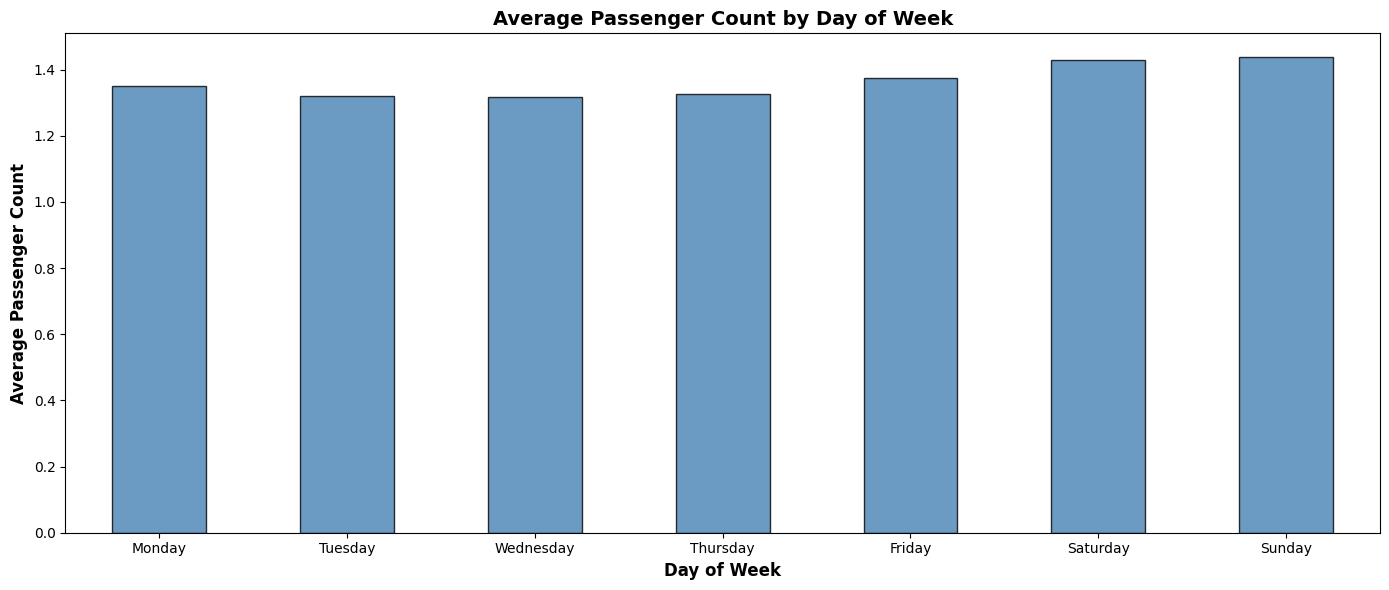

In [434]:
# See how passenger count varies across hours and days

passenger_count_by_weekday = df.groupby(['pickup_day_of_week'])['passenger_count'].mean()

# Create visualization
plt.figure(figsize=(14, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
passenger_count_by_weekday.reindex(day_order).plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Day of Week', fontsize=12, fontweight='bold')
plt.ylabel('Average Passenger Count', fontsize=12, fontweight='bold')
plt.title('Average Passenger Count by Day of Week', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

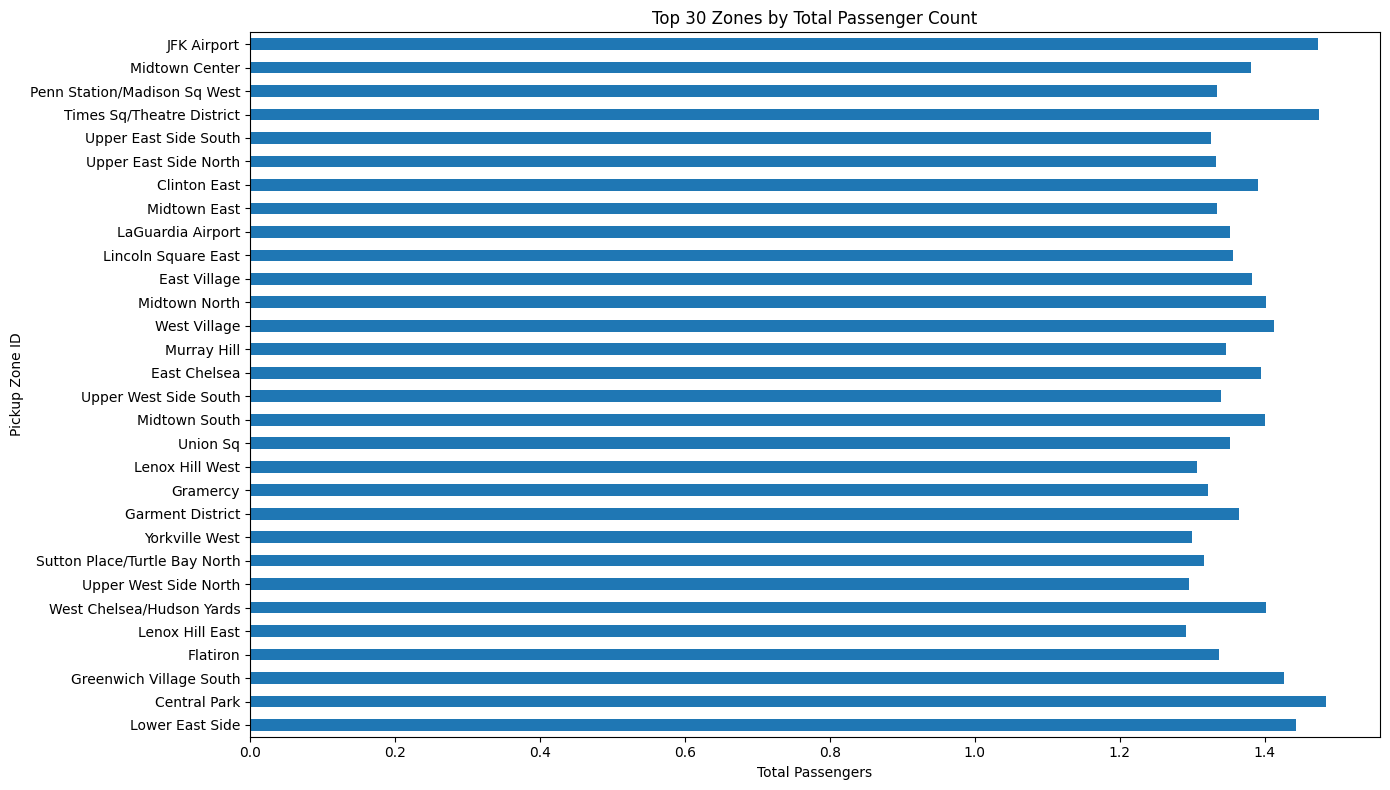

In [455]:
# How does passenger count vary across zones

# Aggregate passenger counts by pickup zone
zone_passengers = df_merged_zone_names.groupby('pickup_zone')['passenger_count'].agg(['sum', 'mean', 'count'])
zone_passengers = zone_passengers.sort_values('sum', ascending=False)
 
# Plot top 30 zones
plt.figure(figsize=(14, 8))
zone_passengers.head(30)['mean'].plot(kind='barh')
plt.xlabel('Total Passengers')
plt.ylabel('Pickup Zone ID')
plt.title('Top 30 Zones by Total Passenger Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

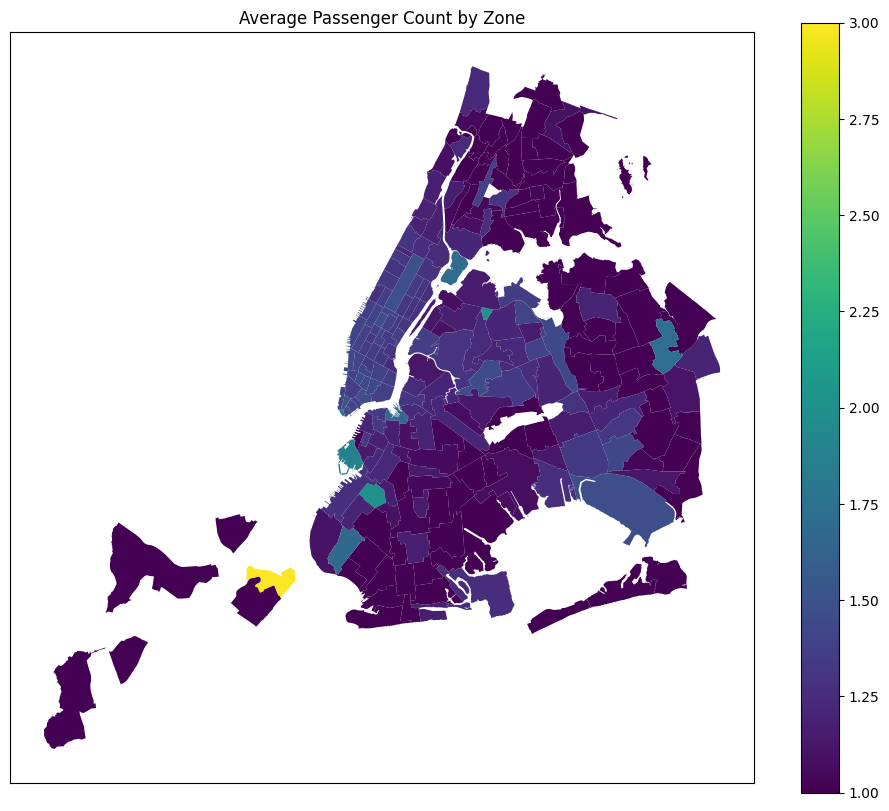

In [471]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

# Create a series with the mean values
avg_passenger_by_zone = df_merged_zone_names.groupby('pickup_zone')['passenger_count'].mean()
 
# Map it to zones dataframe
zones['average_passenger_count'] = zones['zone'].map(avg_passenger_by_zone)

# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))
# Plot the map and display it
zones.plot(column='average_passenger_count', ax=ax,  legend=True)
plt.title('Average Passenger Count by Zone')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

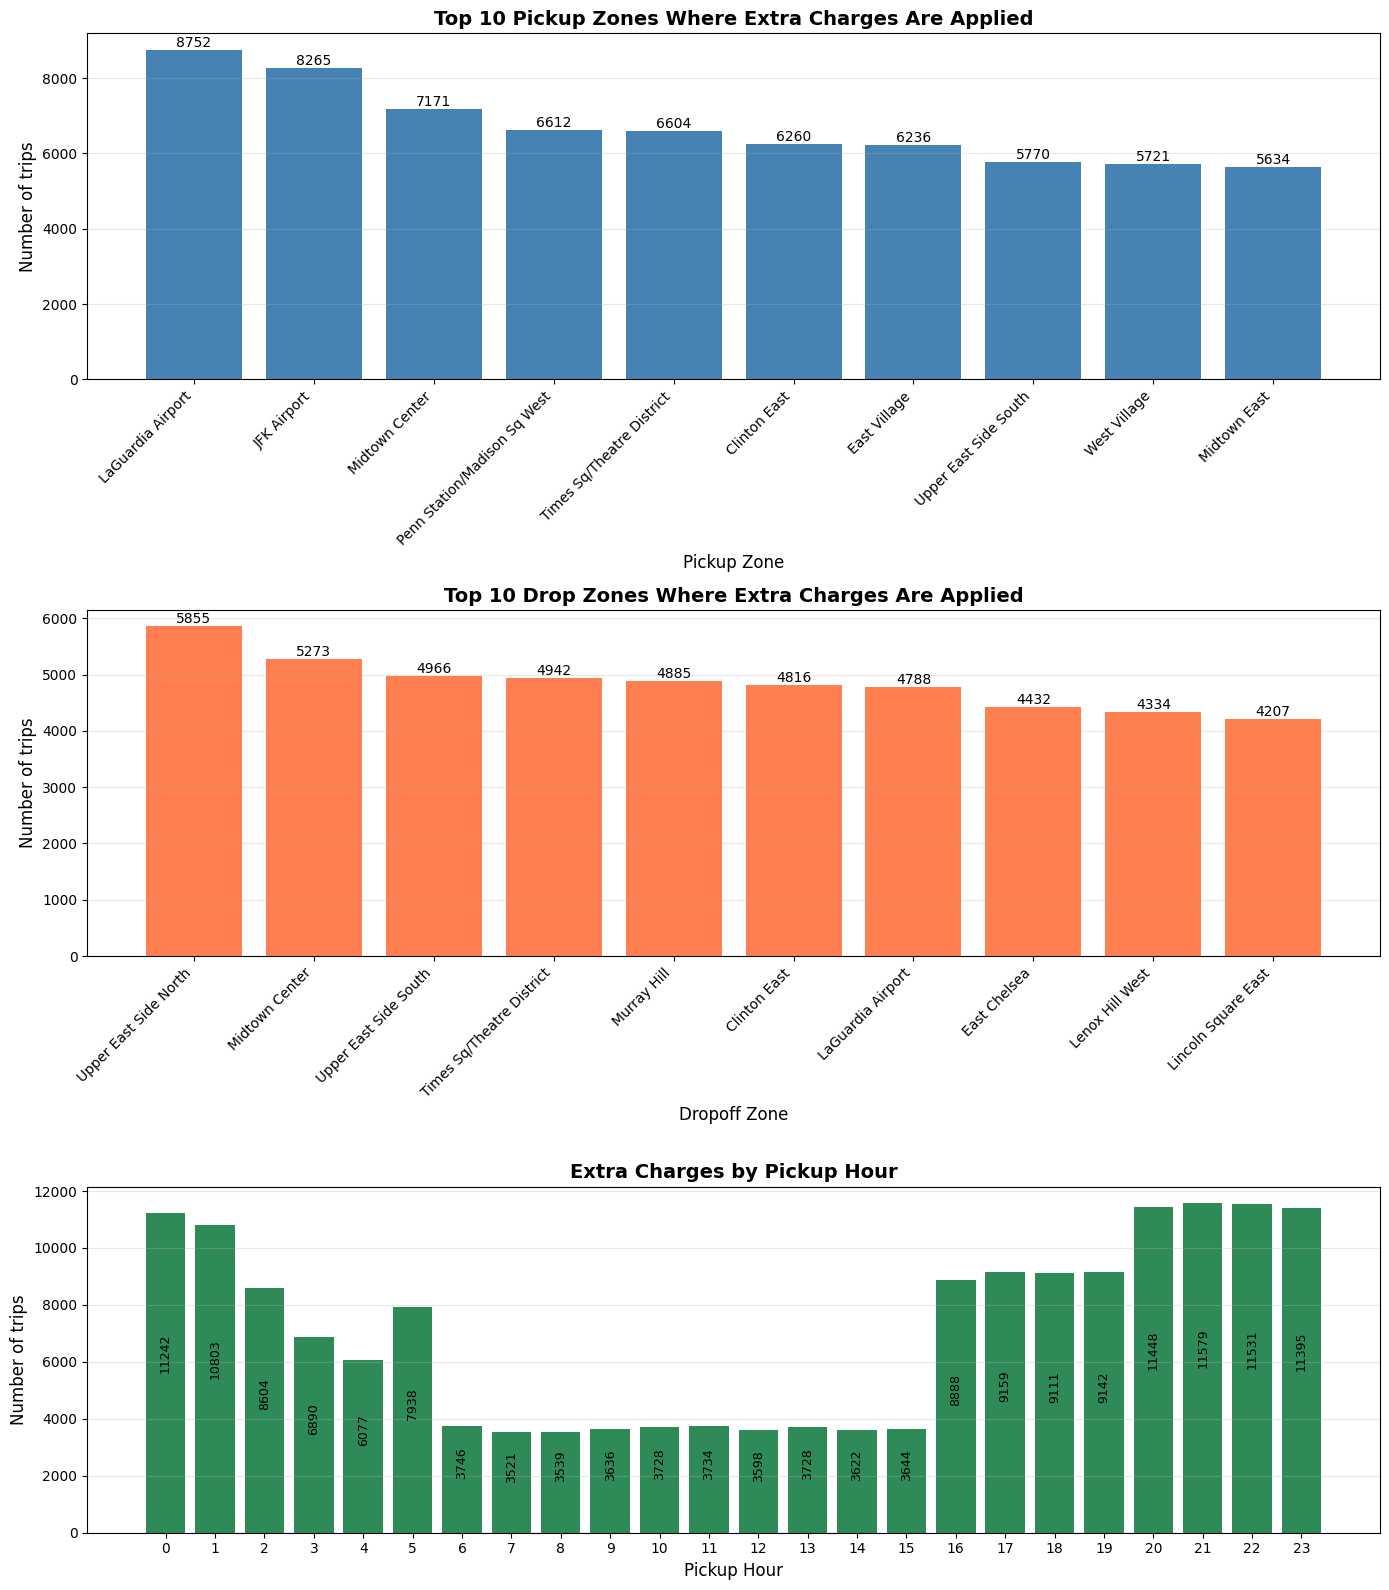

In [481]:
# How often is each surcharge applied?

df_extra_charges = df_merged_zone_names[df_merged_zone_names['extra'] > 0]

df_extra_charges['pickup_zone'].value_counts()
df_extra_charges['dropoff_zone'].value_counts()

df_extra_charges['pickup_hour'].value_counts()



# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
 
# 1. Top 10 pickup zones where extra charges are applied
top_pickup_zones = df_extra_charges['pickup_zone'].value_counts().head(10)
axes[0].bar(range(len(top_pickup_zones)), top_pickup_zones.values, color='steelblue')
axes[0].set_xticks(range(len(top_pickup_zones)))
axes[0].set_xticklabels(top_pickup_zones.index, rotation=45, ha='right')
axes[0].set_xlabel('Pickup Zone', fontsize=12)
axes[0].set_ylabel('Number of trips', fontsize=12)
axes[0].set_title('Top 10 Pickup Zones Where Extra Charges Are Applied', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
 
# Add value labels on bars
for i, v in enumerate(top_pickup_zones.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontsize=10)
 
# 2. Top 10 drop zones where extra charges are applied
top_drop_zones = df_extra_charges['dropoff_zone'].value_counts().head(10)
axes[1].bar(range(len(top_drop_zones)), top_drop_zones.values, color='coral')
axes[1].set_xticks(range(len(top_drop_zones)))
axes[1].set_xticklabels(top_drop_zones.index, rotation=45, ha='right')
axes[1].set_xlabel('Dropoff Zone', fontsize=12)
axes[1].set_ylabel('Number of trips', fontsize=12)
axes[1].set_title('Top 10 Drop Zones Where Extra Charges Are Applied', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
 
# Add value labels on bars
for i, v in enumerate(top_drop_zones.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontsize=10)
 
# 3. Value count of extra charges by pickup hour
extra_by_hour = df_extra_charges['pickup_hour'].value_counts().sort_index()
axes[2].bar(extra_by_hour.index, extra_by_hour.values, color='seagreen')
axes[2].set_xlabel('Pickup Hour', fontsize=12)
axes[2].set_ylabel('Number of trips', fontsize=12)
axes[2].set_title('Extra Charges by Pickup Hour', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(0, 24))
axes[2].grid(axis='y', alpha=0.3)
 
# Add value labels on bars
for i, v in zip(extra_by_hour.index, extra_by_hour.values):
    axes[2].text(i, v/2, str(v), ha='center', va='bottom', fontsize=9, rotation=90)
 
plt.tight_layout()
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

1. Dynamic Fleet Allocation Based on Time Patterns
Peak Hours (6 PM - 12 AM): Deploy maximum fleet capacity during evening rush hours when demand is highest
Off-Peak Hours (4 AM - 5 AM): Reduce fleet size during early morning hours to optimize operational costs
Weekend vs Weekday: Adjust staffing levels as weekends show different demand patterns, with more consistent traffic throughout the day
2. Strategic Zone-Based Positioning
High-Demand Zones: Pre-position vehicles in top pickup zones (JFK Airport, Midtown Center, Penn Station, Upper East Side South, Times Square)
3. Night Operations Strategy (11 PM - 5 AM)
Implement surge pricing during night hours to incentivize driver availability as night hours represent significant revenue opportunity despite lower volume
4. Revenue Maximization
While daytime generates more volume, nighttime shows higher fare-per-mile rates
Focus on High-Value Routes: Prioritize longer-distance trips (5+ miles) which show better economics
Passenger Count Optimization: Encourage multi-passenger trips through pricing incentives

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

Time-Based Positioning Strategy

* Morning Rush (6 AM - 9 AM)
Target zones: Upper East Side, Upper West Side, residential areas of Queens/Brooklyn
Destination anticipation: Stage cabs near Midtown, Financial District for quick pickups after dropoffs

* Midday (10 AM - 3 PM)
Focus on districts: Midtown Center, Penn Station area
Airport coverage: Maintain strong presence at JFK and LaGuardia for business travelers
Tourist zones: Times Square, major attractions

* Evening Rush (4 PM - 8 PM)
Peak demand period - maximum fleet deployment
Position near zones in Midtown, Financial District
Penn Station, Grand Central for commuter connections

* Night Operations (11 PM - 5 AM)
Districts: Times Square, Meatpacking District, East Village
Late-night hubs: Penn Station, Port Authority
Airport focus: JFK for flights
Reduced fleet size but strategic positioning for premium fares

High-Demand Zones (Always maintain strong presence)

* JFK Airport - Highest pickup volume
24/7 coverage recommended
Quick turnaround to Manhattan

* Midtown Center 
Peak coverage during business hours
Reduced presence nights/weekends

* Penn Station/Madison Square West
Commuter hub - align with train schedules
Peak morning/evening coverage

* Upper East Side South

* Times Square/Theatre District
Tourist destination
Evening/night emphasis for shows
Weekend priority


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Peak Hour Premium Pricing
Evening Rush (6-7 PM): Implement High surge pricing (15-20% surge pricing recommended)
Rational: Highest demand period with ~18,000+ trips/hour

Morning Rush (8-9 AM): Implement Moderate surge pricing (10-15% premium)
Rational: Secondary peak with strong commuter demand


Late Night/Early Morning (12 AM - 5 AM): Implement Medium surge pricing (10-15% premium)
Rational: Lower volume, Incentivizes driver availability

Midday (10 AM - 2 PM): Competitive base rates
Rational: Moderate demand period


Distance-Tiered Pricing Strategy

Short Trips (0-2 miles)
Current Issue: Lower tip percentages, less profitable per mile
Strategy:
Implement Minimum fare (like $8-10)
Slightly higher per-mile rate ($3.50-4.00/mile)
Justification: Fixed costs (pickup time, traffic) same regardless of distance

Medium Trips (2-5 miles)
Sweet spot for profitability
Strategy:
Competitive base rate ($3.00-3.25/mile)
Standard pricing to capture volume

Long Trips (5+ miles)
Strategy:
Slightly reduced per-mile rate ($2.50-2.75/mile)
Encourages longer trips
Still profitable due to reduced stop-and-go traffic

Day-of-Week Pricing
Weekdays (Monday-Friday)
Business-focused pricing, Higher base rates justified by Predictable commuter demand
Business expense accounts Time-sensitive customers

Weekends (Saturday-Sunday)
Leisure-focused competitive pricing
Slightly lower base rates (5-10% reduction)
Capture price-sensitive leisure travelers


Zone-Based Pricing
Premium Zones (Higher base rates)
Business districts: Midtown, Financial District
add $1-2 pickup fee for High-value customers, business travelers

Major airports (JFK, LaGuardia, Newark)
Flat-rate options for popular destinations
Example: JFK to Manhattan flat rate (depending on destination)